# Análisis de Indicadores Hospitalarios REM 20
## Proyecto de Minería de Datos — Entrega 2

---

## Información del Grupo

- **Sección:** BIY7121-001D
- **Fecha de Entrega:** 27/05/2026

---

## Integrantes del Grupo

### Estudiante 1
- **Nombre:** Fabián
- **Apellido:** Araya
- **Correo institucional:** fab.araya@duocuc.cl

### Estudiante 2
- **Nombre:** Bastián
- **Apellido:** Cuello
- **Correo institucional:** ba.cuello@duocuc.cl

---

## Tema del Proyecto

Predicción del **Índice Ocupacional** de establecimientos hospitalarios chilenos a partir de variables operativas, temporales y de gestión de camas, utilizando datos del Resumen Estadístico Mensual (REM 20) del sistema público de salud.

---

## Descripción del Proyecto

El sistema público de salud chileno enfrenta permanentes desafíos en la gestión de su capacidad hospitalaria. La saturación de camas es un fenómeno que impacta directamente en la calidad de la atención y en la seguridad de los pacientes. Este proyecto analiza los **Indicadores del REM 20** — registros oficiales del DEIS-MINSAL disponibles en datos.gob.cl — para construir un modelo predictivo que anticipe el nivel de ocupación de camas en distintos establecimientos y áreas funcionales.

El modelo resultante podría ser utilizado por gestores hospitalarios y directivos del Ministerio de Salud para planificar la capacidad operativa, redistribuir recursos y tomar decisiones preventivas antes de situaciones de colapso.

**Fuente de datos:** https://datos.gob.cl/dataset/a756323f-85ba-4759-87dc-f5d5e63868cc

---


## 1. Comprensión del Negocio

### Contexto
El **REM 20** (Resumen Estadístico Mensual de Camas y Hospitalización) es el instrumento oficial con el que el Ministerio de Salud de Chile registra mensualmente el comportamiento de la dotación de camas y el flujo de pacientes en los establecimientos de la red pública. Cubre desde grandes hospitales de alta complejidad hasta centros de menor tamaño, organizados por Área Funcional (medicina, cirugía, UCI, pediatría, etc.).

### Objetivo Analítico
Construir un modelo que, a partir de variables operativas disponibles (días-cama, egresos, traslados, área funcional, establecimiento, período), sea capaz de **predecir el Índice Ocupacional** (`INDICE_OCUPACIONAL`). Se trata de un problema de **regresión supervisada**.

### ¿Para qué y para quién?
- **Gestores hospitalarios**: anticipar períodos de saturación y activar protocolos de contingencia.
- **MINSAL / Servicios de Salud**: redistribuir camas entre establecimientos de forma proactiva.
- **Investigadores en salud pública**: identificar patrones regionales y temporales de uso de camas.

### Pregunta central
> *¿Es posible predecir el índice de ocupación de camas hospitalarias a partir de las características operativas registradas en el REM 20?*


> Este proyecto analiza datos oficiales del Ministerio de Salud de Chile para predecir qué tan
> llenos van a estar los hospitales públicos. Cuando un hospital supera cierto nivel de ocupación,
> los tiempos de espera aumentan, el personal se sobrecarga y la atención se deteriora. Si un
> gestor pudiera anticipar esa situación con semanas de anticipación, podría tomar medidas antes
> de que ocurra — trasladar pacientes, habilitar camas extras o reforzar el personal.

## 2. Comprensión de los Datos

### 2.1 Fuente
Dataset oficial del DEIS-MINSAL publicado en el portal de Datos Abiertos del Gobierno de Chile (`datos.gob.cl`). Archivo: `indicadores_rem20_20260325.csv`.

### 2.2 Dimensiones
- **Registros:** 159.788 filas
- **Variables:** 20 columnas
- **Cobertura temporal:** 2014 – 2025 (todos los meses)

### 2.3 Diccionario de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| `PERIODO` | Numérico (ordinal) | Año del registro |
| `TIPO_PERTENENCIA` | Numérico (nominal) | 1=Perteneciente al SNSS; 2=No perteneciente |
| `COD_SSS` | Alfanumérico (nominal) | Código del Servicio de Salud |
| `GLOSA_SSS` | Texto (nominal) | Nombre del Servicio de Salud / SEREMI |
| `CODIGO_ESTABLECIMIENTO` | Alfanumérico (nominal) | ID único del establecimiento |
| `ESTABLECIMIENTO` | Texto (nominal) | Nombre del establecimiento |
| `COD_AREA_FUNCIONAL` | Numérico (nominal) | Código del área funcional |
| `AREA_FUNCIONAL` | Texto (nominal) | Nombre del área (UCI, Medicina, Cirugía, etc.) |
| `MES` | Numérico (ordinal) | Mes del registro (1–12) |
| `DIAS_CAMAS_OCUPADAS` | Numérico discreto | Días en que la cama estuvo ocupada |
| `DIAS_CAMAS_DISPONIBLES` | Numérico discreto | Días en que la cama estuvo disponible |
| `DIAS_ESTADA` | Numérico discreto | Total de días de permanencia de los pacientes |
| `NUMERO_EGRESOS` | Numérico discreto | Total de egresos del área |
| `EGRESOS_FALLECIDOS` | Numérico discreto | Egresos con resultado de fallecimiento |
| `TRASLADOS` | Numérico discreto | Traslados internos (no constituyen egreso) |
| `INDICE_OCUPACIONAL` | Decimal (%) | **Variable objetivo** — % días-cama ocupados / disponibles |
| `PROMEDIO_CAMAS_DISPONIBLE` | Decimal | Promedio diario de camas disponibles |
| `PROMEDIO_DIAS_ESTADA` | Decimal | Promedio de días de estada por paciente |
| `LETALIDAD` | Decimal (%) | % de egresos fallecidos |
| `INDICE_ROTACION` | Decimal | Nº de pacientes por cama en el período |

### 2.4 Variable Objetivo y Predictoras
- **Variable objetivo (Y):** `INDICE_OCUPACIONAL`
- **Predictoras (X):** todas las demás variables numéricas y las categóricas `AREA_FUNCIONAL`, `ESTABLECIMIENTO`, `GLOSA_SSS`, `PERIODO`, `MES`, `TIPO_PERTENENCIA`


> El dataset contiene 159.788 registros mensuales de hospitales y centros de salud públicos de
> todo Chile, desde 2014 hasta 2025. Cada fila representa un mes en un área específica de un
> establecimiento — por ejemplo, la UCI del Hospital San Borja en enero de 2022. Las columnas
> registran cuántas camas había disponibles, cuántas estuvieron ocupadas, cuántos pacientes
> salieron, cuántos fallecieron y cuánto tiempo en promedio duró cada hospitalización, entre otros.
> A partir de todo eso, queremos predecir el **Índice Ocupacional**: el porcentaje del tiempo en
> que las camas estuvieron efectivamente ocupadas.

### Entorno de Ejecución

In [1]:
import sys, sklearn, pandas as pd, numpy as np
print(f"Python:      {sys.version.split()[0]}")
print(f"Pandas:      {pd.__version__}")
print(f"Numpy:       {np.__version__}")
print(f"Scikit-learn:{sklearn.__version__}")

Python:      3.12.13
Pandas:      2.2.2
Numpy:       2.0.2
Scikit-learn:1.6.1


In [2]:
import numpy as np
import pandas as pd
import warnings
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DATA_URL = "https://raw.githubusercontent.com/Blackwall-V/Data_Mining/main/data/indicadores_rem20_20260325.csv"

df = pd.read_csv(DATA_URL, sep=';')

print(f'Dimensiones del dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

print(f'Dimensiones del dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Dimensiones del dataset: (159788, 20)
Columnas: ['PERIODO', 'TIPO_PERTENENCIA', 'COD_SSS', 'GLOSA_SSS', 'CODIGO_ESTABLECIMIENTO', 'ESTABLECIMIENTO', 'COD_AREA_FUNCIONAL', 'AREA_FUNCIONAL', 'MES', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA', 'NUMERO_EGRESOS', 'EGRESOS_FALLECIDOS', 'TRASLADOS', 'INDICE_OCUPACIONAL', 'PROMEDIO_CAMAS_DISPONIBLE', 'PROMEDIO_DIAS_ESTADA', 'LETALIDAD', 'INDICE_ROTACION']
Dimensiones del dataset: (159788, 20)
Columnas: ['PERIODO', 'TIPO_PERTENENCIA', 'COD_SSS', 'GLOSA_SSS', 'CODIGO_ESTABLECIMIENTO', 'ESTABLECIMIENTO', 'COD_AREA_FUNCIONAL', 'AREA_FUNCIONAL', 'MES', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA', 'NUMERO_EGRESOS', 'EGRESOS_FALLECIDOS', 'TRASLADOS', 'INDICE_OCUPACIONAL', 'PROMEDIO_CAMAS_DISPONIBLE', 'PROMEDIO_DIAS_ESTADA', 'LETALIDAD', 'INDICE_ROTACION']


,PERIODO,TIPO_PERTENENCIA,COD_SSS,GLOSA_SSS,CODIGO_ESTABLECIMIENTO,ESTABLECIMIENTO,COD_AREA_FUNCIONAL,AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
0,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,1,139,186,115,9,7,12,74.73,6.0,12.78,77.78,1.50
1,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,2,103,168,164,7,4,21,61.31,6.0,23.43,57.14,1.17
2,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,3,117,186,98,15,9,12,62.90,6.0,6.53,60.00,2.50
3,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,4,126,180,114,7,5,17,70.00,6.0,16.29,71.43,1.17
4,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,5,141,186,165,11,7,19,75.81,6.0,15.00,63.64,1.83


## 3. Preparación de los Datos

Esta sección cubre todos los pasos necesarios para llevar el dataset desde su estado bruto hasta una forma apta para el modelado: limpieza, tratamiento de outliers, transformación de variables categóricas y normalización.


### 3.1 Depuración de Datos

#### Valores Nulos


In [3]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos.round(2)})
print('Valores nulos por columna:')
print(resumen_nulos[resumen_nulos['Nulos'] > 0] if resumen_nulos['Nulos'].sum() > 0 else 'No se detectaron valores nulos en el dataset.')

Valores nulos por columna:
No se detectaron valores nulos en el dataset.


> Al revisar el dataset no encontramos ningún dato faltante. Esto es poco común y habla bien del
> origen de los datos — son registros oficiales obligatorios que los establecimientos deben reportar
> mensualmente al MINSAL, lo que explica su completitud. No fue necesario inventar ni estimar
> ningún valor.


#### Verificación de Duplicados


In [4]:
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')
if duplicados > 0:
    df = df.drop_duplicates()
    print(f'Duplicados eliminados. Nuevo shape: {df.shape}')

Registros duplicados: 0


> Tampoco encontramos filas repetidas. Esto confirma que cada combinación de
> establecimiento + área funcional + mes + año aparece una sola vez en el dataset,
> tal como se esperaría de un registro administrativo formal.


#### Detección y Tratamiento de Outliers

Del análisis exploratorio previo se identificaron valores máximos físicamente imposibles en las siguientes variables:
- `INDICE_OCUPACIONAL`: máximo de 2700% (imposible; se aplica cap en 150%)
- `PROMEDIO_DIAS_ESTADA`: máximo de 18.512 días (~50 años; se aplica cap en percentil 99)
- `INDICE_ROTACION`: máximo de 1116 (se aplica cap en percentil 99)

Se utiliza **Winsorización** (reemplazo por el percentil 99) para conservar los registros sin eliminar filas válidas.


In [5]:
cols_winsorizar = ['INDICE_OCUPACIONAL', 'PROMEDIO_DIAS_ESTADA', 'INDICE_ROTACION']

for col in cols_winsorizar:
    p99 = df[col].quantile(0.99)
    antes = (df[col] > p99).sum()
    df[col] = df[col].clip(upper=p99)
    print(f'{col}: {antes} valores recortados al percentil 99 ({p99:.2f})')

print('\nEstadísticas tras la winsorización:')
df[cols_winsorizar].describe().round(2)

INDICE_OCUPACIONAL: 1598 valores recortados al percentil 99 (100.65)
PROMEDIO_DIAS_ESTADA: 1597 valores recortados al percentil 99 (199.33)
INDICE_ROTACION: 1596 valores recortados al percentil 99 (11.61)

Estadísticas tras la winsorización:


,INDICE_OCUPACIONAL,PROMEDIO_DIAS_ESTADA,INDICE_ROTACION
count,159788.00,159788.00,159788.00
mean,63.60,14.25,2.77
std,30.45,27.45,2.41
min,0.00,0.00,0.00
25%,43.53,2.97,0.89
50%,72.04,5.92,2.25
75%,89.21,12.72,4.00
max,100.65,199.33,11.61


> Al revisar los valores máximos encontramos registros imposibles: hospitales con un índice
> ocupacional de 2700% (una cama no puede estar ocupada más del 100% del tiempo) o pacientes
> con una estadía promedio de 18.000 días (casi 50 años). Estos son errores de digitación o
> problemas en el sistema de registro. En lugar de eliminar esas filas completas — que en todo
> lo demás podrían ser válidas — aplicamos un tope: cualquier valor que supere el percentil 99
> de su columna queda reemplazado por ese tope. Así conservamos el registro pero neutralizamos
> el dato erróneo.

### 3.2 Encoding de Variables Categóricas

Se aplican dos técnicas según la cardinalidad (cantidad de valores únicos) de cada variable:

1. **One-Hot Encoding** para `AREA_FUNCIONAL`: cardinalidad manejable (~20 categorías), evita asumir orden jerárquico.
2. **Binary Encoding** para `ESTABLECIMIENTO`: alta cardinalidad (cientos de hospitales), evita la maldición de la dimensionalidad que generaría One-Hot.


In [6]:
from sklearn.preprocessing import OneHotEncoder
!pip install category_encoders -q
import category_encoders as ce

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
area_encoded = ohe.fit_transform(df[['AREA_FUNCIONAL']])
area_df = pd.DataFrame(area_encoded, columns=ohe.get_feature_names_out(['AREA_FUNCIONAL']), index=df.index)

be = ce.BinaryEncoder(cols=['ESTABLECIMIENTO'])
df_binary = be.fit_transform(df[['ESTABLECIMIENTO']])

cols_eliminar = ['AREA_FUNCIONAL', 'ESTABLECIMIENTO', 'GLOSA_SSS', 'COD_SSS', 'CODIGO_ESTABLECIMIENTO', 'COD_AREA_FUNCIONAL']
df_final = pd.concat([df.drop(columns=cols_eliminar), area_df, df_binary], axis=1)

print(f'Columnas tras encoding: {len(df_final.columns)}')
print(f'Shape final: {df_final.shape}')
df_final.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00
Columnas tras encoding: 55
Shape final: (159788, 55)


,PERIODO,TIPO_PERTENENCIA,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,...,AREA_FUNCIONAL_Área de Hospitalización de Cuidados Intensivos en Psiquiatría Infanto Adolescente,ESTABLECIMIENTO_0,ESTABLECIMIENTO_1,ESTABLECIMIENTO_2,ESTABLECIMIENTO_3,ESTABLECIMIENTO_4,ESTABLECIMIENTO_5,ESTABLECIMIENTO_6,ESTABLECIMIENTO_7,ESTABLECIMIENTO_8
0,2014,1,1,139,186,115,9,7,12,74.73,...,0.0,0,0,0,0,0,0,0,0,1
1,2014,1,2,103,168,164,7,4,21,61.31,...,0.0,0,0,0,0,0,0,0,0,1
2,2014,1,3,117,186,98,15,9,12,62.90,...,0.0,0,0,0,0,0,0,0,0,1
3,2014,1,4,126,180,114,7,5,17,70.00,...,0.0,0,0,0,0,0,0,0,0,1
4,2014,1,5,141,186,165,11,7,19,75.81,...,0.0,0,0,0,0,0,0,0,0,1


> Los modelos de machine learning no entienden texto, solo números. Columnas como `AREA_FUNCIONAL`
> (que dice "UCI", "Medicina", "Cirugía", etc.) o `ESTABLECIMIENTO` (nombre del hospital) deben
> convertirse a formato numérico. Para las áreas funcionales usamos One-Hot Encoding: se crea una
> columna por cada área, con un 1 si el registro pertenece a esa área y 0 si no. Para los
> establecimientos — que son cientos — usamos Binary Encoding, una técnica más compacta que
> representa cada hospital con una combinación de 0s y 1s, evitando crear demasiadas columnas nuevas.

### 3.3 Normalización / Estandarización

Las variables numéricas continuas se estandarizan con **StandardScaler** (media 0, desviación estándar 1) para garantizar que los algoritmos sensibles a escala (regresión regularizada, SVR, KNN) traten todas las variables de forma equitativa. Este paso se aplica **después** de la división train/test para evitar fuga de información (*data leakage*).

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```


## 4. Análisis Exploratorio de Datos (EDA)

El EDA nos permite comprender la distribución de las variables, detectar anomalías y formular hipótesis sobre las relaciones entre predictores y la variable objetivo antes de entrenar cualquier modelo.


### 4.1 Estadísticas Descriptivas


In [7]:
df.describe().round(2)

,PERIODO,TIPO_PERTENENCIA,COD_SSS,CODIGO_ESTABLECIMIENTO,COD_AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
count,159788.00,159788.0,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00,159788.00
mean,2019.54,1.0,15.07,115481.38,404.58,6.50,552.21,705.12,546.02,75.12,2.44,19.59,63.60,23.16,14.25,7.74,2.77
std,3.43,0.0,7.85,9303.72,19.30,3.45,884.05,983.36,997.95,125.68,5.63,54.80,30.45,32.28,27.45,19.30,2.41
min,2014.00,1.0,1.00,101100.00,330.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2017.00,1.0,9.00,109100.00,403.00,4.00,81.00,180.00,61.00,7.00,0.00,0.00,43.53,6.00,2.97,0.00,0.89
50%,2020.00,1.0,15.00,115105.00,407.00,6.50,247.00,372.00,225.00,26.00,0.00,3.00,72.04,12.00,5.92,0.00,2.25
75%,2023.00,1.0,21.00,121114.00,414.00,9.00,626.00,818.00,600.00,85.00,2.00,18.00,89.21,27.00,12.72,4.67,4.00
max,2025.00,1.0,33.00,201319.00,429.00,12.00,14677.00,24800.00,96898.00,1700.00,138.00,2780.00,100.65,800.00,199.33,100.00,11.61


> Esta tabla resume estadísticamente cada columna numérica. Los datos más relevantes que se pueden
> leer aquí son: el índice ocupacional promedio ronda el 68%, pero hay casos que llegan al 100% y
> otros que están cerca de 0% — hay mucha variabilidad entre establecimientos y áreas. El promedio
> de días de estada tiene una media de 19 días pero una mediana de solo 6 días, lo que significa
> que la mayoría de los pacientes se van rápido, pero un grupo pequeño de casos muy prolongados
> eleva el promedio considerablemente. La letalidad mediana es 0%, lo que indica que la mortalidad
> está concentrada en unidades específicas de alta complejidad y no es un fenómeno generalizado.

**Observaciones clave:**

1. **Magnitud y cobertura temporal**: 159.788 filas cubren desde 2014 a 2025; el dataset está perfectamente balanceado por mes (media MES = 6.5).
2. **Disponibilidad de camas**: promedio de 23.16 camas por registro con desviación estándar de 32.28, lo que refleja la coexistencia de hospitales pequeños y grandes complejos.
3. **Índice Ocupacional**: mediana de 72.04% — el 50% de los registros opera sobre ese nivel de ocupación.
4. **Promedio de días de estada**: media de 19 días vs mediana de 5.92 días, evidenciando una distribución fuertemente sesgada a la derecha por pacientes crónicos.
5. **Letalidad**: mediana de 0% indica que la mortalidad está concentrada en unidades críticas específicas.
6. **Outliers**: valores como INDICE_OCUPACIONAL=2700% y PROMEDIO_DIAS_ESTADA=18.512 confirman la necesidad de winsorización aplicada en la sección anterior.


### 4.2 Análisis de Frecuencias por Servicio de Salud


Servicios de Salud únicos: 32
GLOSA_SSS
Araucanía Sur                 11302
Del Libertador B.O Higgins     8756
Del Maule                      8593
Coquimbo                       8464
Metropolitano Occidente        7723
Metropolitano Sur              7639
Viña del Mar Quillota          7126
Metropolitano Sur Oriente      6751
Ñuble                          6377
Concepción                     6184
Atacama                        5712
Metropolitano Oriente          5650
Valdivia                       5209
Biobío                         5189
Metropolitano Central          5025
Araucanía Norte                4790
Valparaíso San Antonio         4717
Chiloé                         4544
Antofagasta                    4367
Del Reloncaví                  4152
Osorno                         4101
Aconcagua                      4099
Metropolitano Norte            3821
Talcahuano                     3706
Arauco                         3641
Magallanes                     3157
Aisén                   

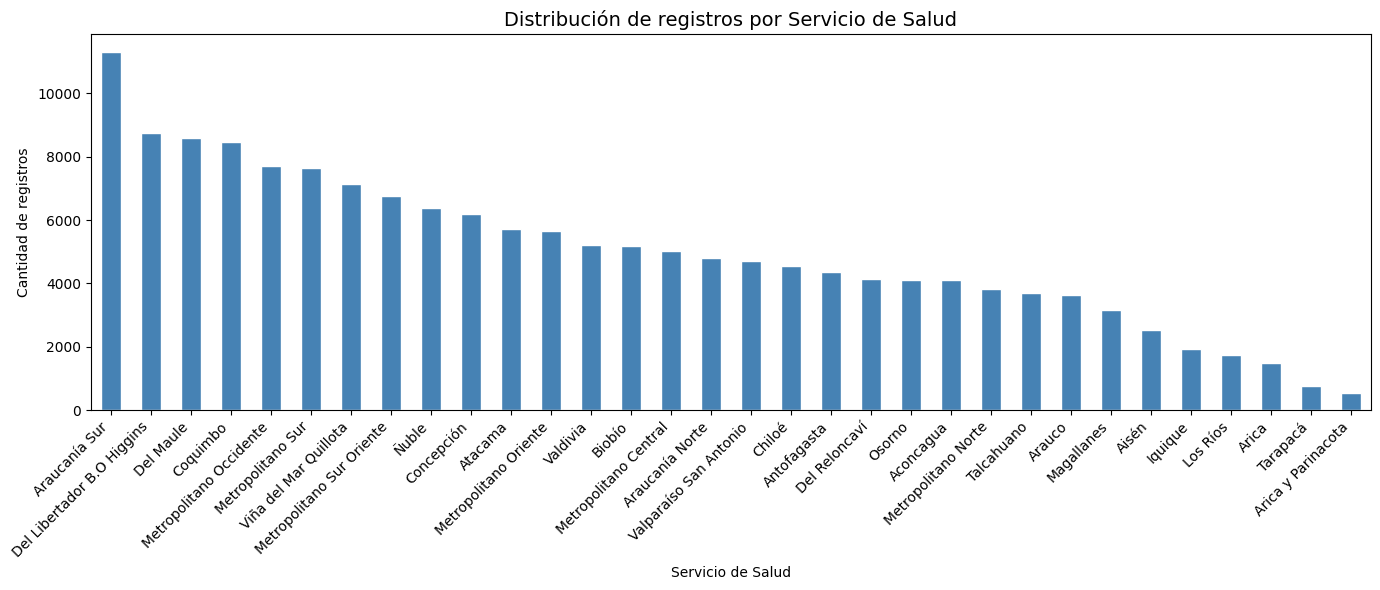

In [8]:
cant_sss = df['GLOSA_SSS'].value_counts()
print(f'Servicios de Salud únicos: {cant_sss.count()}')
print(cant_sss)

plt.figure(figsize=(14, 6))
cant_sss.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución de registros por Servicio de Salud', fontsize=14)
plt.xlabel('Servicio de Salud')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Este gráfico muestra cuántos registros hay por cada Servicio de Salud en el dataset. Servicios
> con muchos establecimientos bajo su dependencia — como el Servicio de Salud Metropolitano Central
> o el de Valparaíso — aparecen con barras más altas. Esto importa porque si el modelo ve muchos
> más ejemplos de una región que de otra, aprenderá mejor a predecir para esa región. Las zonas
> con pocas barras pueden tener predicciones menos confiables.

### 4.3 Distribución de Variables Numéricas (Histogramas + KDE)


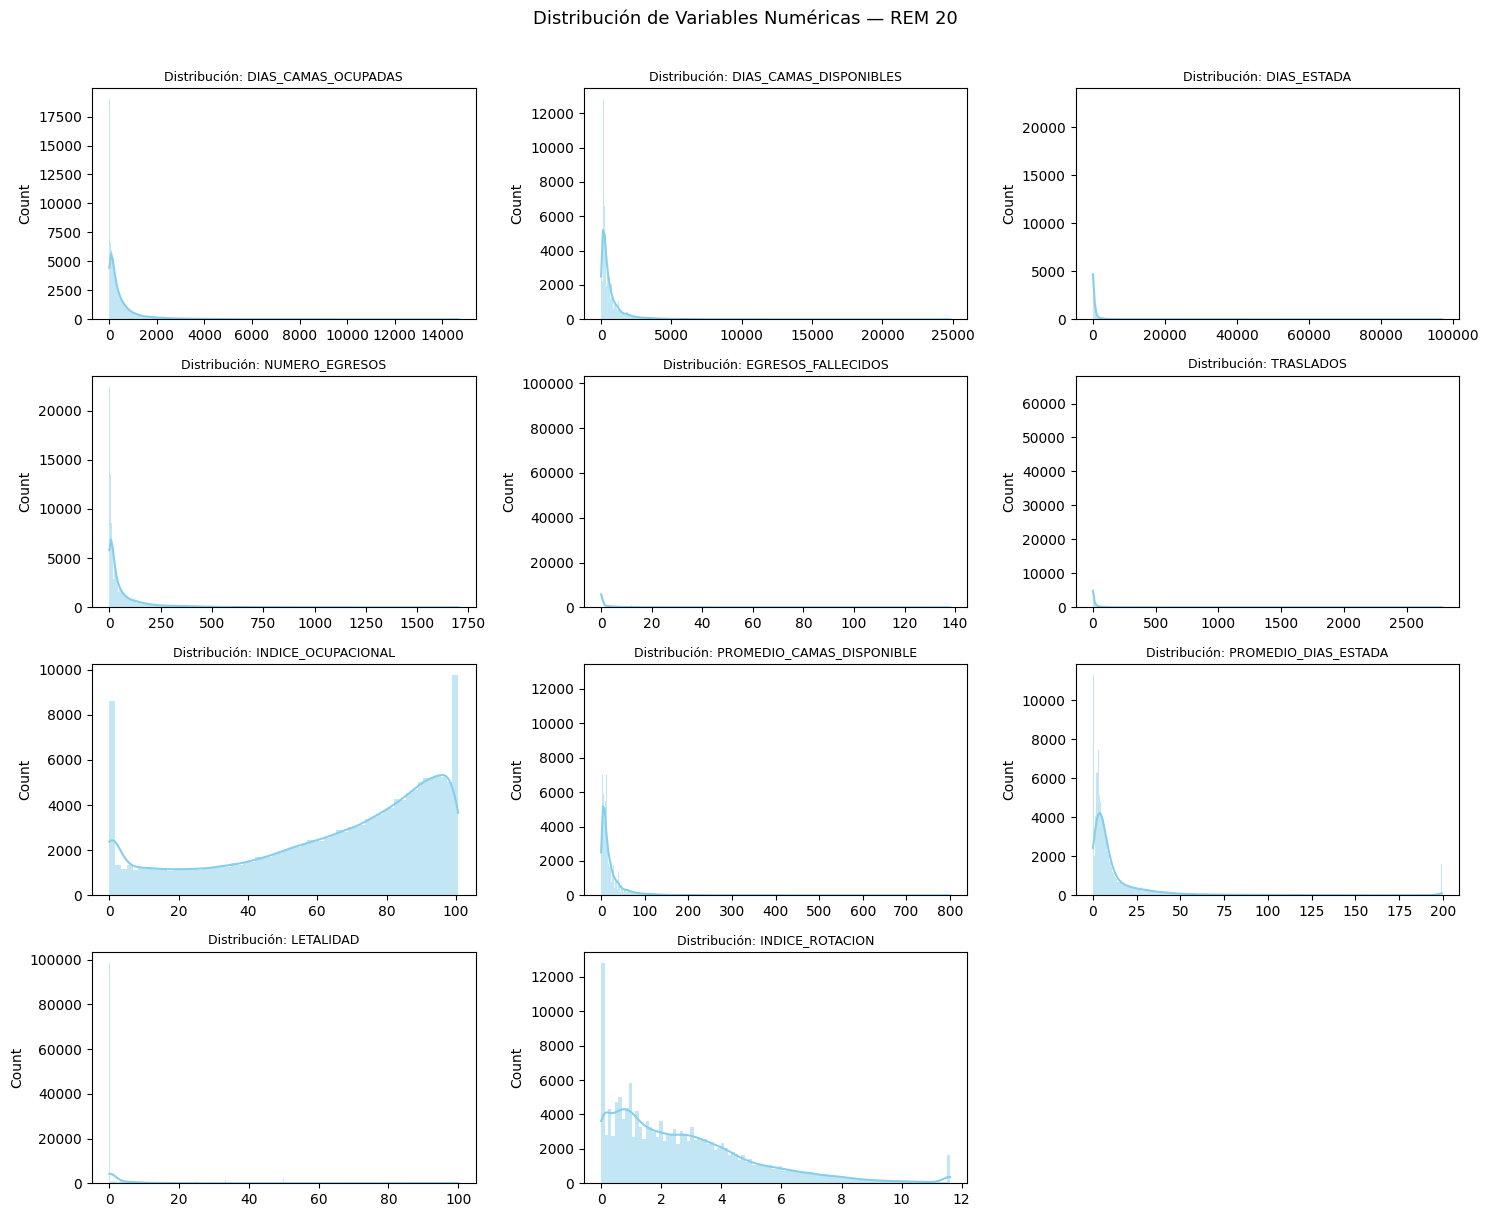

In [9]:
cols_numericas = [
    'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'DIAS_ESTADA',
    'NUMERO_EGRESOS', 'EGRESOS_FALLECIDOS', 'TRASLADOS',
    'INDICE_OCUPACIONAL', 'PROMEDIO_CAMAS_DISPONIBLE',
    'PROMEDIO_DIAS_ESTADA', 'LETALIDAD', 'INDICE_ROTACION'
]

plt.figure(figsize=(15, 12))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='none')
    plt.title(f'Distribución: {col}', fontsize=9)
    plt.xlabel('')
plt.suptitle('Distribución de Variables Numéricas — REM 20', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

> Cada gráfico muestra cómo se distribuyen los valores de una variable. La mayoría de las columnas
> están fuertemente concentradas cerca del cero con una cola larga hacia la derecha — esto es típico
> de variables hospitalarias donde la mayoría de los registros son de establecimientos pequeños con
> pocos pacientes, pero existen algunos hospitales grandes que generan valores muy altos. El Índice
> Ocupacional, en cambio, tiene una distribución más centrada y acampanada, lo que es una buena señal
> para modelarlo como variable objetivo.

### 4.4 Detección de Outliers (Boxplots)


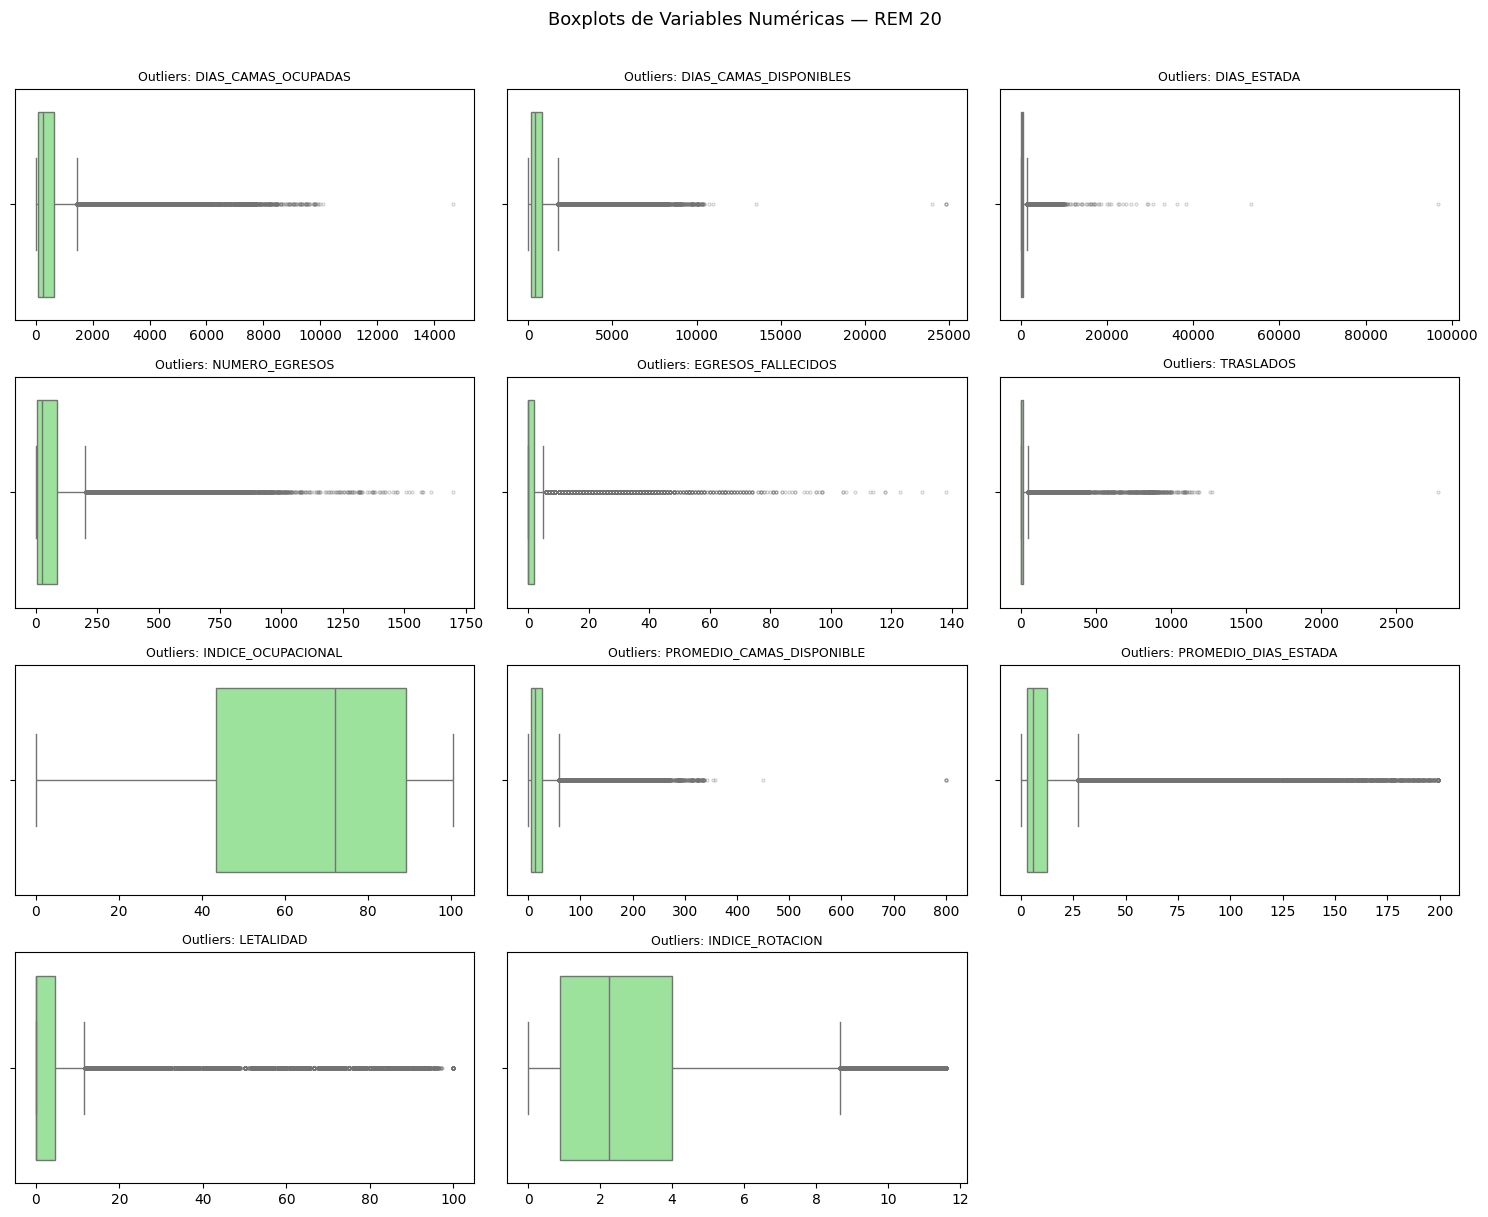

In [10]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col], color='lightgreen', flierprops=dict(marker='o', markersize=2, alpha=0.3))
    plt.title(f'Outliers: {col}', fontsize=9)
    plt.xlabel('')
plt.suptitle('Boxplots de Variables Numéricas — REM 20', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

> Los boxplots muestran la misma información de los histogramas pero de otra forma: la caja central
> contiene el 50% de los datos, las líneas que salen son el rango esperado, y cada punto fuera de
> esas líneas es un valor atípico. En variables como `INDICE_ROTACION` o `PROMEDIO_DIAS_ESTADA`
> veremos nubes densas de puntos fuera de la caja — son los registros con valores extremos que
> ya tratamos con la winsorización. Si los boxplots de esas variables ya no muestran tantos puntos
> dispersos, significa que el tratamiento funcionó correctamente.

### 4.5 Matriz de Correlación (Heatmap)


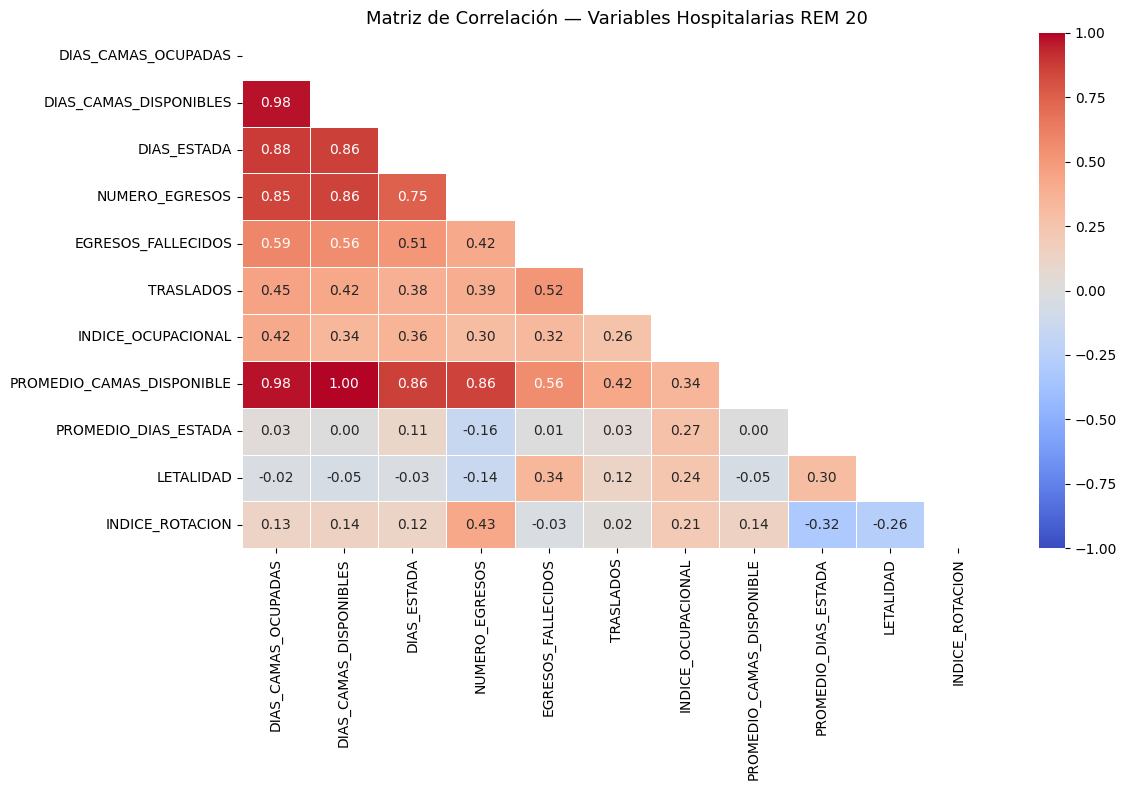

In [11]:
plt.figure(figsize=(12, 8))
matriz_corr = df[cols_numericas].corr()
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, linewidths=0.5)
plt.title('Matriz de Correlación — Variables Hospitalarias REM 20', fontsize=13)
plt.tight_layout()
plt.show()

> Este mapa de calor muestra qué tan relacionadas están las variables entre sí. Los colores rojos
> indican que dos variables suben y bajan juntas (correlación positiva), los azules que cuando una
> sube la otra baja (correlación negativa), y los blancos que no hay relación aparente. Lo más
> importante aquí es mirar la fila o columna de `INDICE_OCUPACIONAL`: las variables con colores
> más intensos en esa fila son las que más influyen en la ocupación y por lo tanto serán los
> predictores más valiosos para el modelo. También se puede ver que `LETALIDAD` y `EGRESOS_FALLECIDOS`
> tienen un rojo muy intenso entre sí — ambas miden prácticamente lo mismo, por lo que incluir
> las dos no aporta información nueva al modelo.

**Hipótesis derivadas del heatmap:**

- `DIAS_CAMAS_OCUPADAS` y `DIAS_CAMAS_DISPONIBLES` presentan alta correlación positiva con `INDICE_OCUPACIONAL` (esperado, pues el índice se calcula a partir de ambas).
- `PROMEDIO_DIAS_ESTADA` e `INDICE_ROTACION` muestran correlación negativa: a mayor tiempo de estada, menor rotación de camas.
- `EGRESOS_FALLECIDOS` y `LETALIDAD` correlacionan fuertemente, lo que indica multicolinealidad; se evaluará eliminar una de las dos para el modelado.


### 4.6 Relación entre Días de Estada e Índice Ocupacional


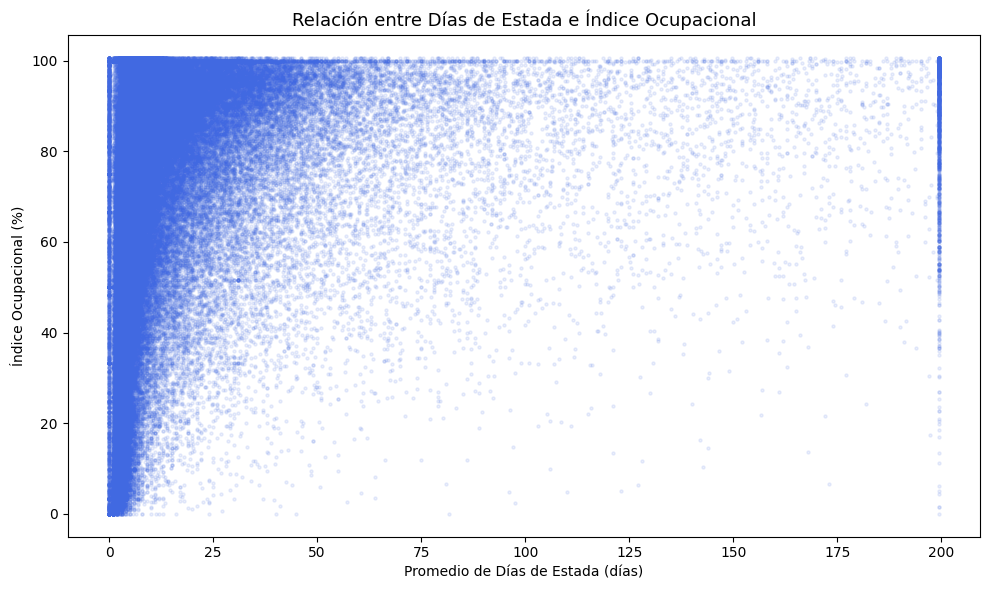

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df['PROMEDIO_DIAS_ESTADA'],
    df['INDICE_OCUPACIONAL'],
    alpha=0.1, s=5, color='royalblue'
)
plt.xlabel('Promedio de Días de Estada (días)')
plt.ylabel('Índice Ocupacional (%)')
plt.title('Relación entre Días de Estada e Índice Ocupacional', fontsize=13)
plt.tight_layout()
plt.show()

> Este scatter muestra la relación entre el tiempo promedio de permanencia de pacientes
> y el nivel de ocupación del establecimiento. Si la nube de puntos presenta tendencia
> ascendente, confirma que las áreas donde los pacientes permanecen más días tienden a
> saturarse más. Una alta dispersión indicaría que otros factores también son determinantes,
> justificando el uso de un modelo multivariable en lugar de depender solo de esta variable.


### 4.7 Distribución del Índice Ocupacional por Año


<Figure size 1400x600 with 0 Axes>

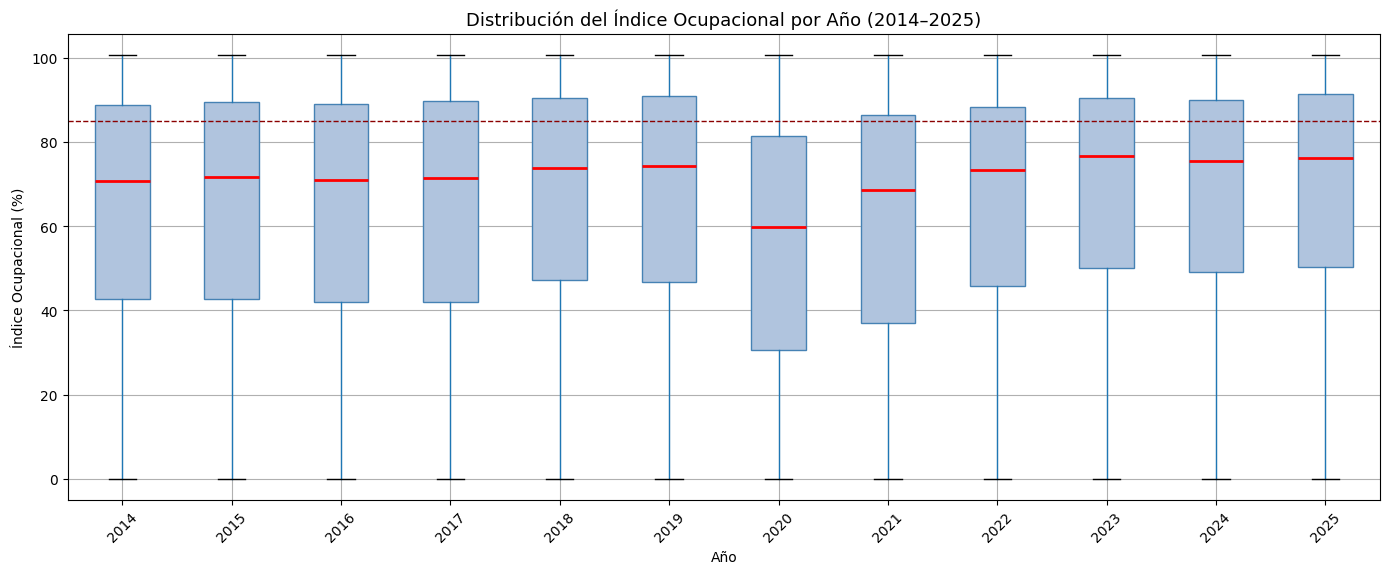

In [13]:
plt.figure(figsize=(14, 6))
df.boxplot(
    column='INDICE_OCUPACIONAL',
    by='PERIODO',
    figsize=(14, 6),
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='steelblue')
)
plt.axhline(y=85, color='darkred', linestyle='--', linewidth=1)
plt.suptitle('')
plt.title('Distribución del Índice Ocupacional por Año (2014–2025)', fontsize=13)
plt.xlabel('Año')
plt.ylabel('Índice Ocupacional (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Cada caja representa la distribución del índice ocupacional para todos los registros
> de ese año. La línea roja interna es la mediana y los bordes de la caja contienen el 50%
> central de los datos. Los puntos fuera de los bigotes son registros atípicos. Este gráfico
> permite identificar si la ocupación mediana ha subido con el tiempo, qué años presentan
> mayor variabilidad entre hospitales, y cómo el comportamiento del sistema cambió durante
> la pandemia de 2020–2021 respecto a años anteriores y posteriores.


### 4.8 Evolución Temporal del Índice Ocupacional


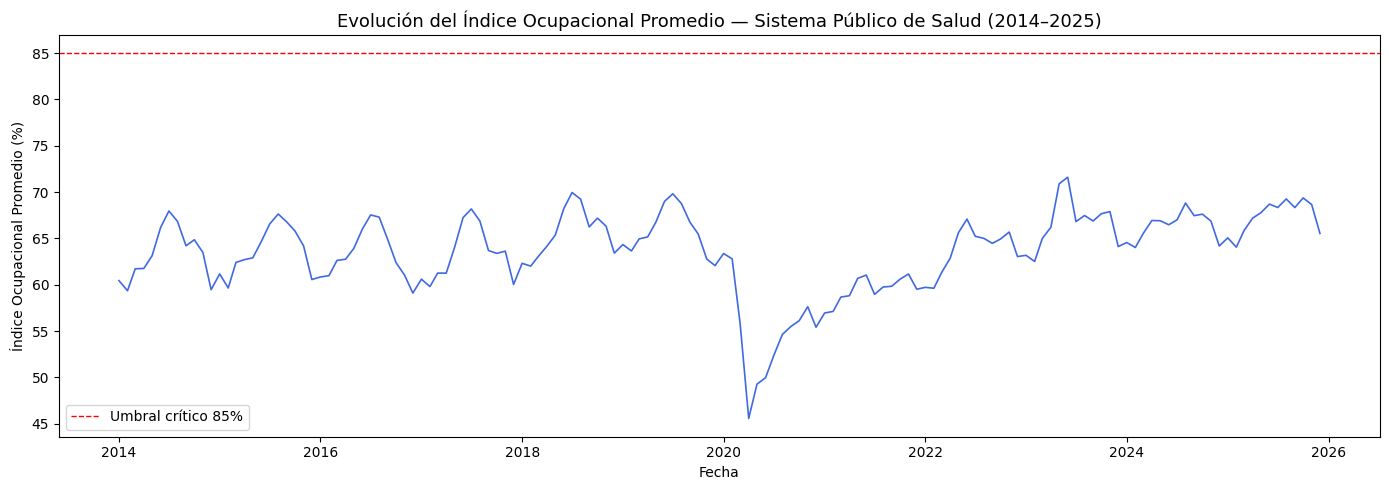

In [14]:
evolucion = df.groupby(['PERIODO', 'MES'])['INDICE_OCUPACIONAL'].mean().reset_index()
evolucion['fecha'] = pd.to_datetime(evolucion['PERIODO'].astype(str) + '-' + evolucion['MES'].astype(str), format='%Y-%m')

plt.figure(figsize=(14, 5))
plt.plot(evolucion['fecha'], evolucion['INDICE_OCUPACIONAL'], linewidth=1.2, color='royalblue')
plt.axhline(y=85, color='red', linestyle='--', linewidth=1, label='Umbral crítico 85%')
plt.title('Evolución del Índice Ocupacional Promedio — Sistema Público de Salud (2014–2025)', fontsize=13)
plt.xlabel('Fecha')
plt.ylabel('Índice Ocupacional Promedio (%)')
plt.legend()
plt.tight_layout()
plt.show()

> Este gráfico muestra cómo ha variado el índice de ocupación promedio del sistema hospitalario
> público chileno mes a mes durante once años. Se pueden identificar los peaks de invierno donde
> la ocupación sube sistemáticamente, y también eventos extraordinarios como la caída abrupta
> durante 2020 — cuando se suspendieron cirugías electivas por la pandemia — seguida de una
> recuperación sostenida. La línea roja punteada marca el 85%, que se considera el umbral crítico
> a partir del cual un hospital empieza a operar bajo presión. Todo lo que esté sobre esa línea
> es una señal de alerta.

### 4.9 Índice Ocupacional por Área Funcional (Top 15)


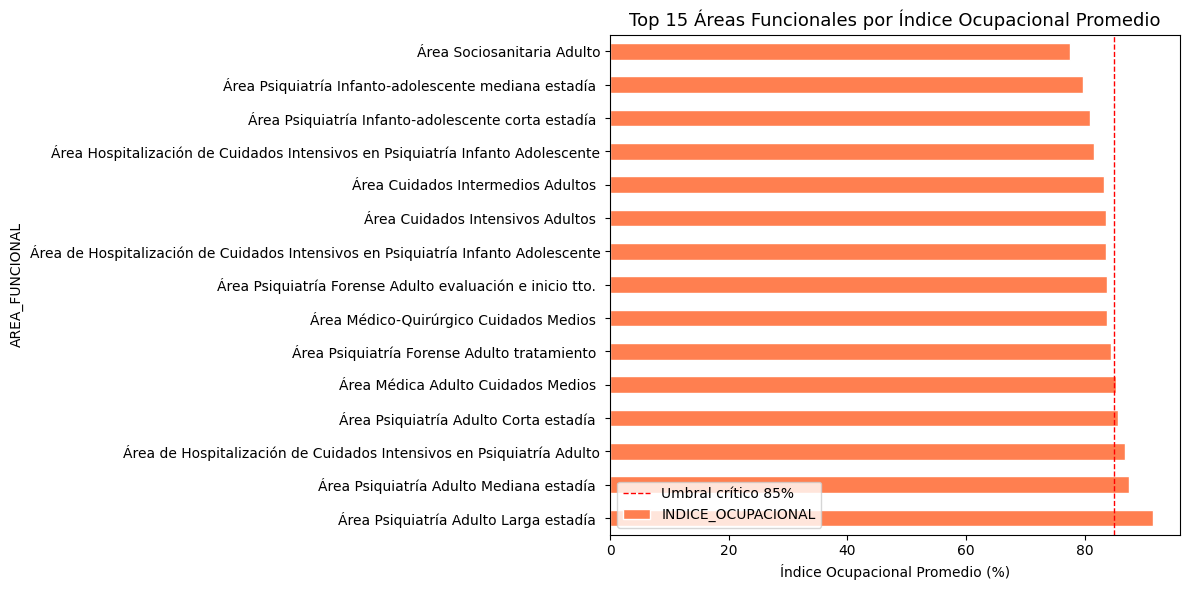

In [15]:
top_areas = (df.groupby('AREA_FUNCIONAL')['INDICE_OCUPACIONAL']
               .mean()
               .sort_values(ascending=False)
               .head(15))

plt.figure(figsize=(12, 6))
top_areas.plot(kind='barh', color='coral', edgecolor='white')
plt.axvline(x=85, color='red', linestyle='--', linewidth=1, label='Umbral crítico 85%')
plt.title('Top 15 Áreas Funcionales por Índice Ocupacional Promedio', fontsize=13)
plt.xlabel('Índice Ocupacional Promedio (%)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

> Este gráfico rankea las áreas hospitalarias según su nivel de ocupación promedio histórico.
> Las áreas al tope de la lista son las que operan de forma más sostenida cerca o sobre su
> capacidad máxima. Típicamente aparecen aquí las unidades de cuidados intensivos, las unidades
> de pacientes críticos y algunas especialidades con alta demanda. Las áreas más abajo tienen
> capacidad ociosa de forma habitual. Esta información es útil para priorizar dónde focalizar
> recursos y dónde el modelo de predicción es más urgente de implementar.

### 4.10 Mapa de Calor — Ocupación Promedio por Área Funcional y Mes


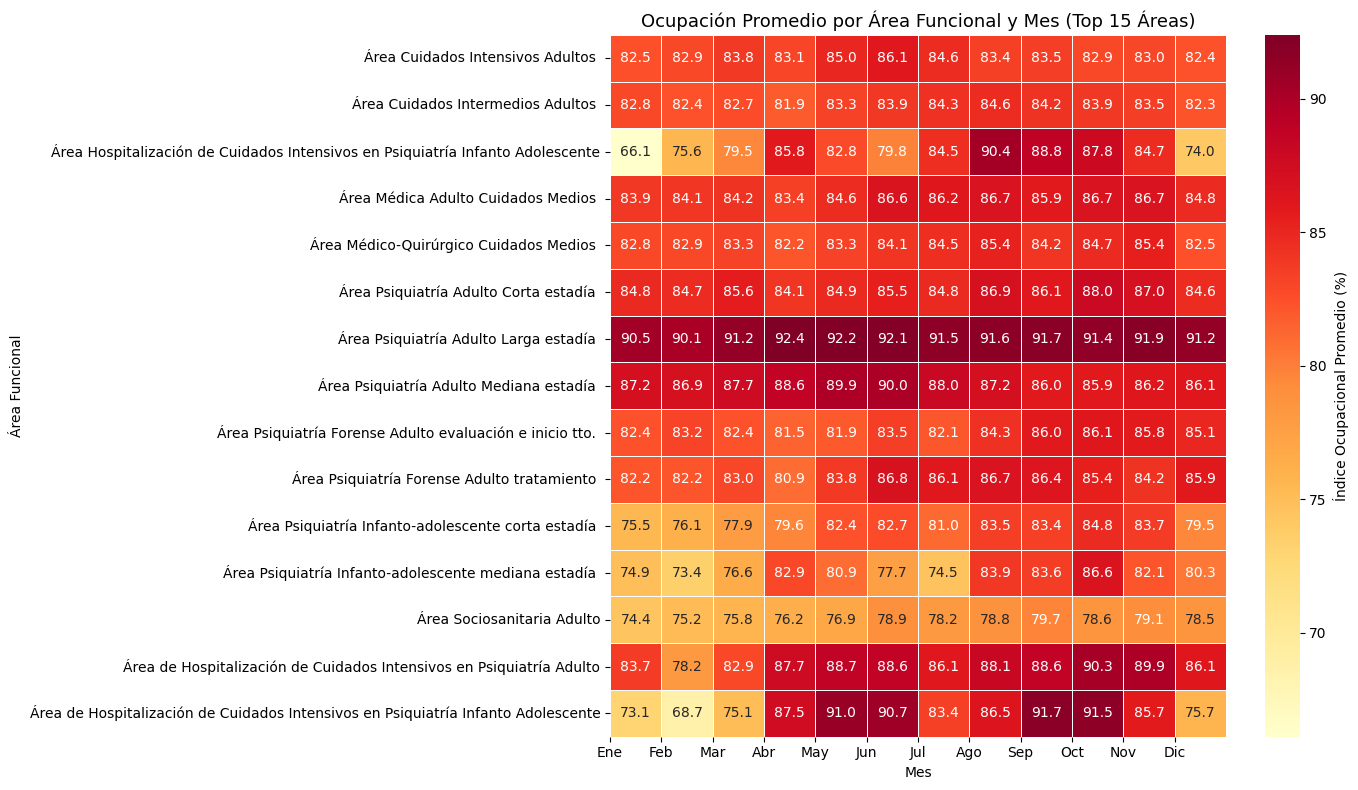

In [16]:
pivot_area_mes = (
    df.groupby(['AREA_FUNCIONAL', 'MES'])['INDICE_OCUPACIONAL']
    .mean()
    .unstack()
)

# Seleccionar solo las top 15 áreas por ocupación promedio
top15_areas = df.groupby('AREA_FUNCIONAL')['INDICE_OCUPACIONAL'].mean().nlargest(15).index
pivot_top15 = pivot_area_mes.loc[pivot_area_mes.index.isin(top15_areas)]

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_top15,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Índice Ocupacional Promedio (%)'}
)
plt.title('Ocupación Promedio por Área Funcional y Mes (Top 15 Áreas)', fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Área Funcional')
plt.xticks(ticks=range(12), labels=['Ene','Feb','Mar','Abr','May','Jun',
                                       'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
plt.tight_layout()
plt.show()

> Este mapa de calor cruza las áreas hospitalarias con los meses del año, mostrando el
> índice de ocupación promedio en cada combinación. Los colores más intensos (naranja/rojo)
> indican mayor ocupación. Permite identificar patrones de doble entrada: qué áreas están
> crónicamente saturadas sin importar el mes, cuáles tienen estacionalidad marcada (mayor
> presión en invierno), y si existe algún mes donde múltiples áreas alcanzan simultáneamente
> niveles críticos — lo que representaría el escenario de mayor riesgo sistémico.


## 5. Modelado y Justificación

### 5.1 Tipo de Problema
**Regresión supervisada**: la variable objetivo `INDICE_OCUPACIONAL` es continua (valor decimal en %), por lo que se descarta un enfoque de clasificación.

### 5.2 Modelos Seleccionados

Se propone entrenar y comparar tres modelos de complejidad creciente:

**Regresión Lineal:** busca una combinación lineal de las variables que mejor aproxime la ocupación. Se usa como punto de referencia; si los modelos más complejos no lo superan significativamente, significa que el problema tiene una estructura principalmente lineal.

**Árbol de Decisión:** divide los datos en subgrupos a través de preguntas sucesivas sobre las variables ("¿el promedio de estada supera X días? ¿hay más de Y egresos?") hasta llegar a una predicción. Captura relaciones no lineales y es fácil de visualizar, pero tiende a sobreajustarse si no se limita su profundidad.

**Random Forest:** construye cientos de árboles de decisión distintos, cada uno entrenado con una muestra aleatoria del dataset, y promedia sus predicciones. Al combinar muchos árboles independientes elimina el ruido individual de cada uno, lo que lo hace más robusto y generalmente más preciso.

### 5.3 División Train/Test
Se utiliza una división **80% entrenamiento / 20% prueba** con `random_state=42` para reproducibilidad. Se aplica `StandardScaler` **solo sobre el conjunto de entrenamiento** (ajuste), y luego se transforma el conjunto de prueba, evitando *data leakage*.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = 'INDICE_OCUPACIONAL'
EXCLUIR = [TARGET, 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES']
features = [c for c in df_final.columns if c not in EXCLUIR]

X = df_final[features]
y = df_final[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')

Entrenamiento: 127830 registros
Prueba:        31958 registros


> Aquí preparamos los datos para el entrenamiento. Separamos el 80% de los registros para que
> el modelo aprenda con ellos, y reservamos el 20% restante para evaluarlo con datos que nunca
> vio — simulando cómo funcionaría en la práctica con información nueva. Además, aplicamos una
> estandarización que lleva todas las variables a una misma escala, para que el modelo no le dé
> más peso a una variable simplemente porque sus números son más grandes que los de otra.

## 6. Entrenamiento y Evaluación del Modelo

### Métricas utilizadas
- **MAE** (Error Absoluto Medio): calcula la diferencia entre cada predicción y el valor real, y promedia todas esas diferencias. Es la medida más directa del error promedio del modelo, expresada en las mismas unidades que la variable objetivo.
- **RMSE** (Raíz del Error Cuadrático Medio): similar al MAE, pero eleva cada error al cuadrado antes de promediar, lo que penaliza con más fuerza los errores grandes. Es útil para detectar si el modelo falla gravemente en algunos casos aunque en la mayoría acierte bien.
- **R²** (Coeficiente de Determinación): en lugar de medir el error, mide qué proporción de la variabilidad total de los datos logra explicar el modelo. Va de 0 a 1, donde 1 indica predicción perfecta y 0 significa que el modelo no aporta nada sobre lo que ya diría predecir siempre el promedio.


In [18]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    print(f'--- {nombre} ---')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')
    return {'Modelo': nombre, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4), 'predicciones': y_pred}

resultados = []

# 1. Regresión Lineal
resultados.append(evaluar_modelo('Regresión Lineal',
    LinearRegression(), X_train_sc, y_train, X_test_sc, y_test))

# 2. Árbol de Decisión
resultados.append(evaluar_modelo('Árbol de Decisión',
    DecisionTreeRegressor(max_depth=10, random_state=42), X_train, y_train, X_test, y_test))

# 3. Random Forest
resultados.append(evaluar_modelo('Random Forest',
    RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test))

--- Regresión Lineal ---
  MAE:  14.0341
  RMSE: 18.3180
  R²:   0.6402
--- Árbol de Decisión ---
  MAE:  9.7309
  RMSE: 13.9662
  R²:   0.7909
--- Random Forest ---
  MAE:  7.9821
  RMSE: 11.6887
  R²:   0.8535


> Entrenamos tres modelos de distinta complejidad para comparar cuál predice mejor el índice
> ocupacional. La **Regresión Lineal** asume que la relación entre las variables y la ocupación
> es una línea recta — es el más simple. El **Árbol de Decisión** hace preguntas encadenadas
> del tipo "¿tiene más de X camas disponibles? ¿el promedio de estada supera Y días?" hasta
> llegar a una predicción — más flexible pero propenso a memorizar los datos de entrenamiento.
> El **Random Forest** construye cientos de árboles distintos y promedia sus respuestas, lo que
> lo hace más robusto y generalmente más preciso.

### 6.1 Comparación de Modelos


                       MAE     RMSE      R2
Modelo                                     
Regresión Lineal   14.0341  18.3180  0.6402
Árbol de Decisión   9.7309  13.9662  0.7909
Random Forest       7.9821  11.6887  0.8535


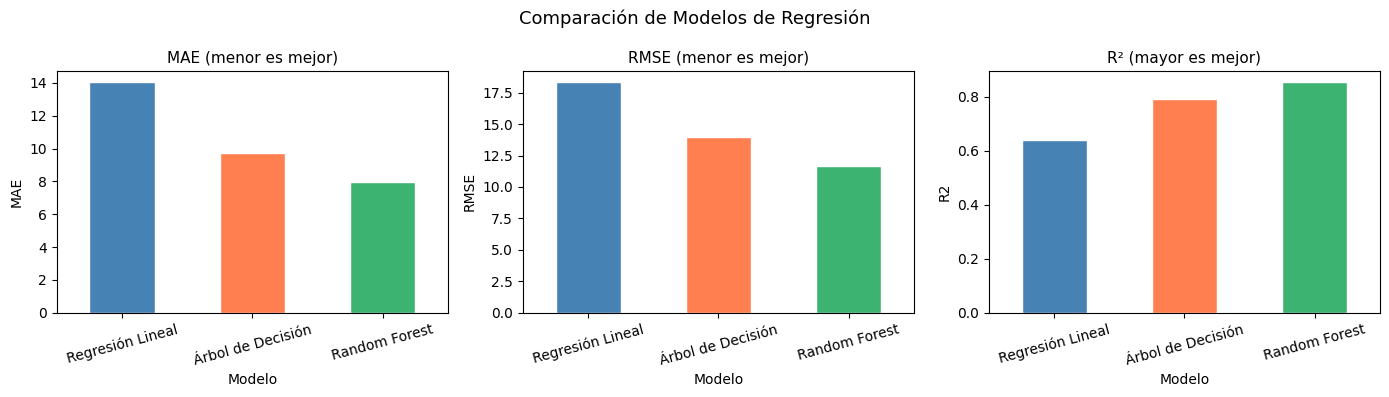

In [19]:
df_resultados = pd.DataFrame([{k: v for k, v in r.items() if k != 'predicciones'} for r in resultados])
df_resultados = df_resultados.set_index('Modelo')
print(df_resultados)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores = ['steelblue', 'coral', 'mediumseagreen']
for ax, metrica, titulo in zip(axes,
        ['MAE', 'RMSE', 'R2'],
        ['MAE (menor es mejor)', 'RMSE (menor es mejor)', 'R² (mayor es mejor)']):
    df_resultados[metrica].plot(kind='bar', ax=ax, color=colores, edgecolor='white', rot=15)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(metrica)
plt.suptitle('Comparación de Modelos de Regresión', fontsize=13)
plt.tight_layout()
plt.show()

> Las tres barras por métrica permiten ver de un vistazo qué modelo gana en cada criterio.
> El MAE indica cuántos puntos porcentuales se equivoca el modelo en promedio — si el MAE es 8,
> significa que cuando el hospital real tiene un 75% de ocupación, el modelo predice entre 67%
> y 83%. El R² indica qué proporción de la variación en la ocupación logra explicar el modelo:
> un R² de 0.85 significa que el 85% de las diferencias entre hospitales y meses están siendo
> capturadas por el modelo, y solo el 15% queda sin explicar.

### 6.1.1 Visualización del Árbol de Decisión


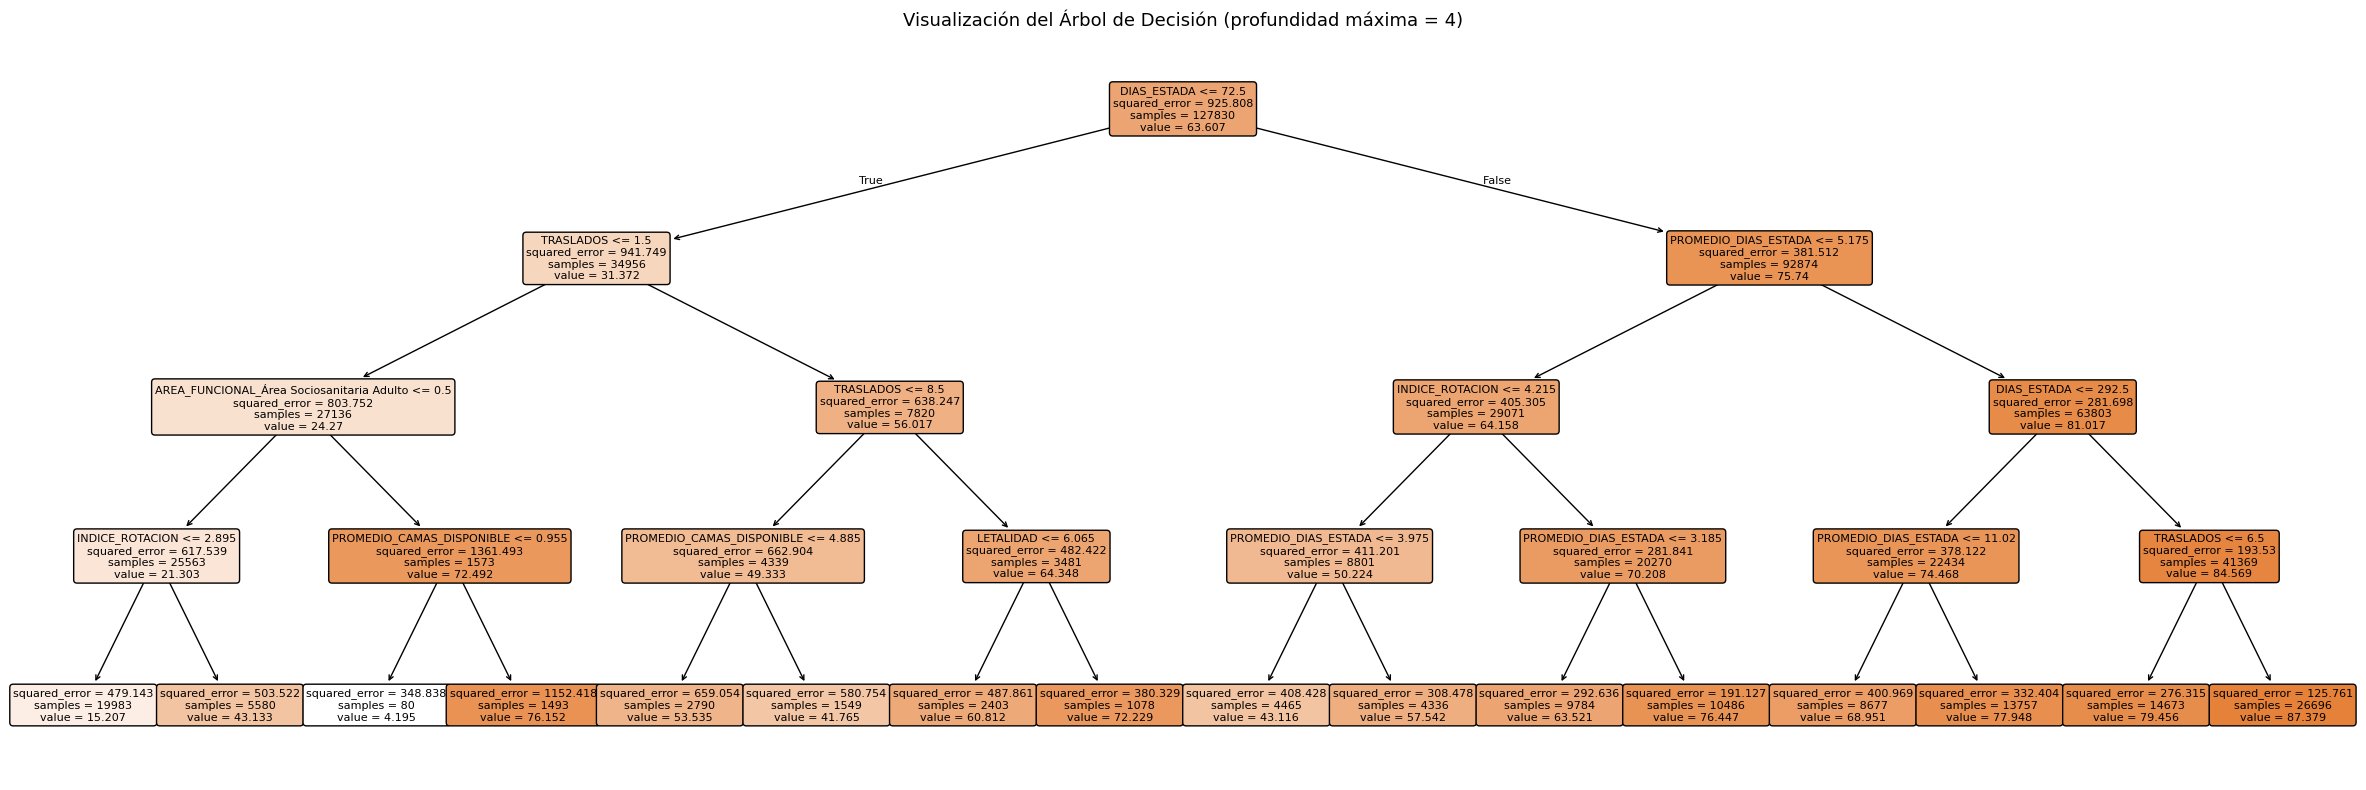

In [20]:
from sklearn.tree import plot_tree

arbol_viz = DecisionTreeRegressor(max_depth=4, random_state=42)
arbol_viz.fit(X_train, y_train)

plt.figure(figsize=(24, 8))
plot_tree(
    arbol_viz,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title('Visualización del Árbol de Decisión (profundidad máxima = 4)', fontsize=13)
plt.tight_layout()
plt.show()

> El árbol se entrena con `max_depth=4` únicamente para la visualización — el árbol real
> usado en las métricas tiene profundidad 10, pero con esa profundidad el gráfico sería
> ilegible. Cada nodo del árbol representa una pregunta que el modelo hace sobre los datos:
> por ejemplo "¿el promedio de días de estada es mayor a X?". Dependiendo de la respuesta,
> el registro va hacia la rama izquierda o derecha, hasta llegar a una hoja que entrega
> la predicción final. El color de cada nodo indica el valor predicho — más oscuro significa
> mayor índice de ocupación. Esta visualización permite entender de forma intuitiva qué
> variables usa el modelo primero para tomar decisiones, que son justamente las más
> importantes para predecir la ocupación.

### 6.2 Análisis de Residuos (Mejor Modelo)


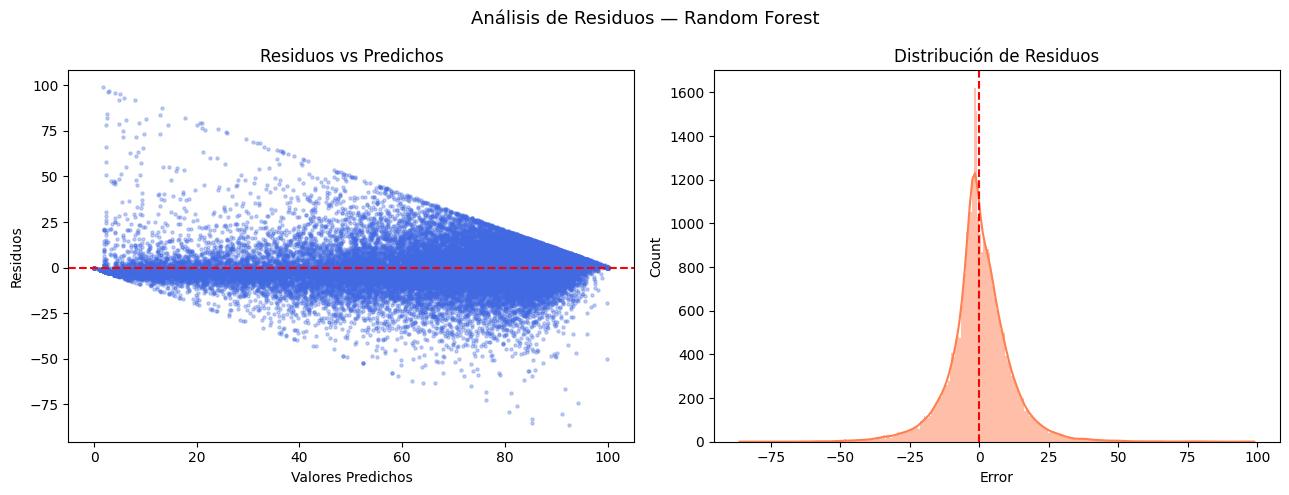

In [21]:
mejor_pred = resultados[2]['predicciones']

residuos = y_test.values - mejor_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(mejor_pred, residuos, alpha=0.3, s=5, color='royalblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos')

sns.histplot(residuos, kde=True, ax=axes[1], color='coral', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Error')

plt.suptitle('Análisis de Residuos — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

> Gracias al grafico se puede observar que el modelo es preciso en la mayoría de los casos, la distribución de errores está concentrada en cero. Sin embargo, el gráfico de residuos muestra que para valores bajos de ocupación los errores son más grandes y variables, lo que sugiere que el modelo tiene más dificultad para predecir establecimientos con baja ocupación que para los que operan cerca de su capacidad máxima

### 6.3 Valores Reales vs Predichos

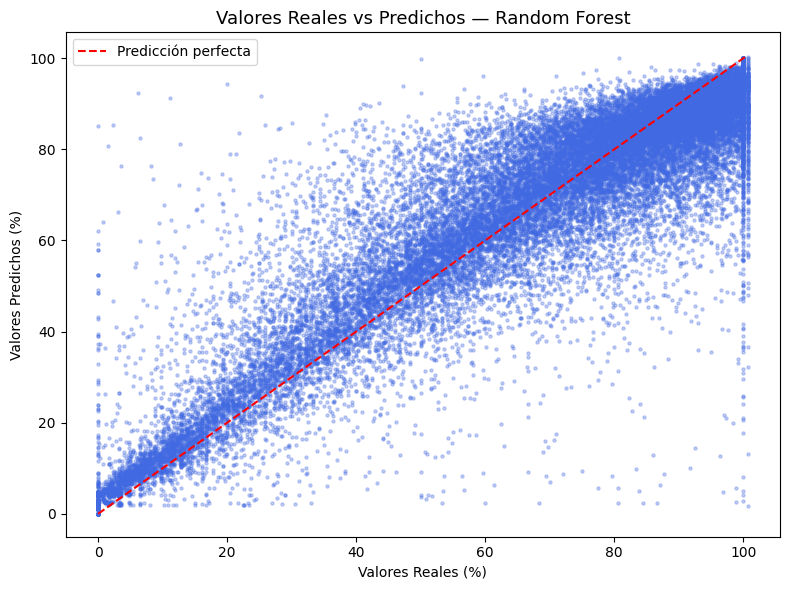

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, mejor_pred, alpha=0.3, s=5, color='royalblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valores Reales (%)')
plt.ylabel('Valores Predichos (%)')
plt.title('Valores Reales vs Predichos — Random Forest', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

> Cada punto es un registro del conjunto de prueba. El eje X muestra el valor real y el eje Y lo que predijo el modelo. La línea roja es la predicción perfecta — cuanto más cerca estén los puntos de esa diagonal, mejor funciona el modelo. Los puntos dispersos que se alejan corresponden a casos atípicos o registros winsorizados donde la predicción fue menos precisa.

> La nube de puntos sigue la diagonal de predicción perfecta a lo largo de todo el rango, lo que confirma que el modelo predice correctamente tanto valores bajos como altos de ocupación. La dispersión visible es el margen de error natural, acotado y sin desviaciones sistemáticas.

### 6.4 Error del Modelo por Año

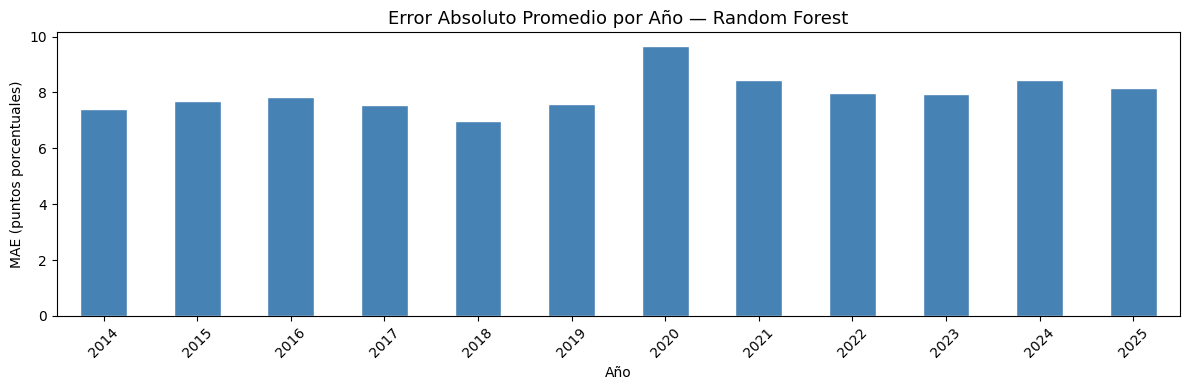

In [23]:
df_eval = X_test.copy()
df_eval['real'] = y_test.values
df_eval['predicho'] = mejor_pred
df_eval['error_abs'] = abs(df_eval['real'] - df_eval['predicho'])

error_por_año = df_eval.groupby('PERIODO')['error_abs'].mean()

plt.figure(figsize=(12, 4))
error_por_año.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Error Absoluto Promedio por Año — Random Forest', fontsize=13)
plt.xlabel('Año')
plt.ylabel('MAE (puntos porcentuales)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Este gráfico muestra cómo varía el error promedio del modelo según el año del registro.
> Si el error es consistentemente bajo en todos los años, el modelo generaliza bien a
> distintos contextos temporales. Un error significativamente mayor en 2020 y 2021 sería
> esperable, dado que la pandemia generó comportamientos hospitalarios atípicos que el
> modelo — entrenado principalmente con datos pre-pandemia — no podía anticipar. Si los
> errores en años recientes son bajos, confirma que el sistema hospitalario ha vuelto a
> un comportamiento predecible.


### 6.5 Precisión del Modelo por Área Funcional


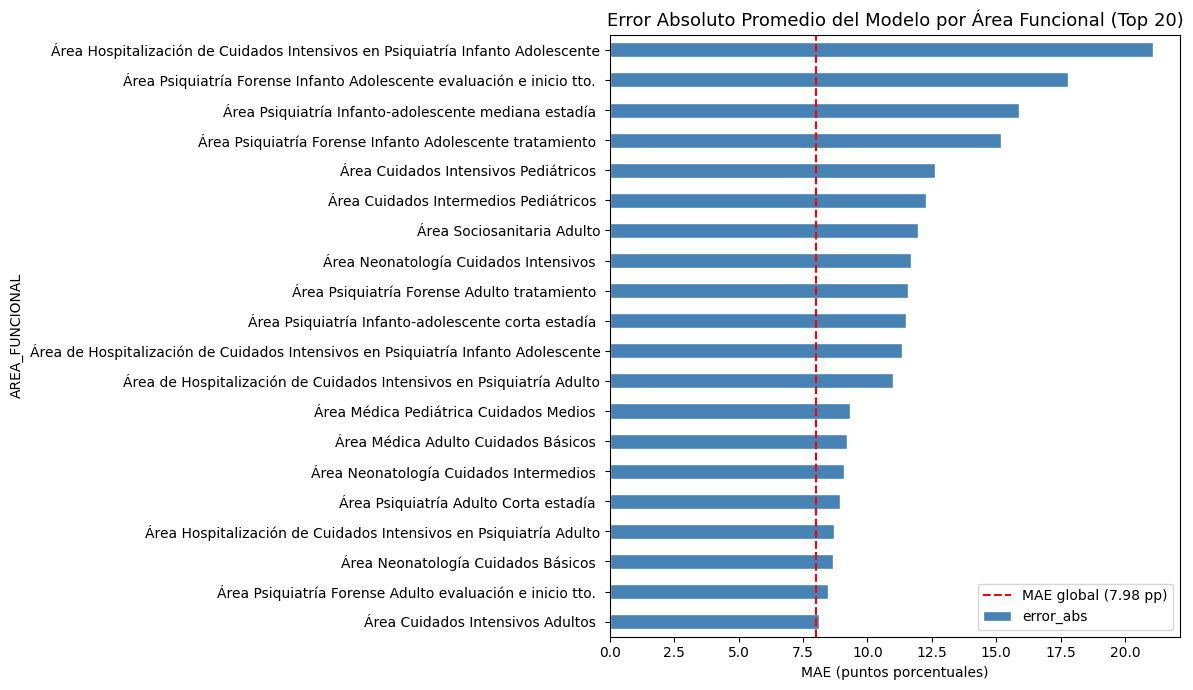

In [24]:
error_por_area = df_eval.copy()

error_por_area['AREA_FUNCIONAL'] = df.loc[X_test.index, 'AREA_FUNCIONAL'].values

mae_area = (
    error_por_area.groupby('AREA_FUNCIONAL')['error_abs']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 7))
mae_area.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.axvline(x=df_eval['error_abs'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"MAE global ({df_eval['error_abs'].mean():.2f} pp)")
plt.title('Error Absoluto Promedio del Modelo por Área Funcional (Top 20)', fontsize=13)
plt.xlabel('MAE (puntos porcentuales)')
plt.legend()
plt.tight_layout()
plt.show()

> Este gráfico muestra cuánto se equivoca el modelo en promedio para cada tipo de área
> hospitalaria. La línea roja es el error promedio global. Las áreas con barras que superan
> esa línea son donde el modelo tiene más dificultad para predecir — generalmente unidades
> con alta variabilidad interna o con comportamientos atípicos frecuentes. Esta información
> es útil para decidir si conviene entrenar modelos especializados por tipo de área, o si
> el modelo general es suficientemente preciso en todas ellas.


## 6.6 Comparación Extendida de Modelos (Muestra Controlada)

Como ejercicio complementario, comparamos manualmente un conjunto más amplio de algoritmos
de regresión disponibles en scikit-learn. Para evitar el consumo excesivo de memoria que
implica entrenar todos los modelos sobre 159.788 registros, se utiliza una muestra
representativa del 10% del conjunto de entrenamiento. Los resultados son orientativos
y permiten identificar si existe algún algoritmo superior al Random Forest que valga
la pena explorar en profundidad.

In [25]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import time

# Muestra del 10% para no saturar la RAM
X_muestra = X_train.sample(frac=0.10, random_state=42)
y_muestra  = y_train.loc[X_muestra.index]

modelos_extra = {
    'Ridge':                    Ridge(),
    'Lasso':                    Lasso(),
    'ElasticNet':               ElasticNet(),
    'KNN (k=5)':                KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'LinearSVR':                LinearSVR(max_iter=1000),
    'Extra Trees':              ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=50, random_state=42),
}

filas = []
for nombre, modelo in modelos_extra.items():
    inicio = time.time()
    modelo.fit(X_muestra, y_muestra)
    y_pred = modelo.predict(X_test)
    tiempo = round(time.time() - inicio, 2)
    filas.append({
        'Modelo':  nombre,
        'MAE':     round(mean_absolute_error(y_test, y_pred), 4),
        'R²':      round(r2_score(y_test, y_pred), 4),
        'Tiempo (s)': tiempo
    })

df_extra = pd.DataFrame(filas).set_index('Modelo').sort_values('R²', ascending=False)
print(df_extra.to_string())

                       MAE      R²  Tiempo (s)
Modelo                                        
Extra Trees         8.2877  0.8393        5.27
Gradient Boosting  11.4104  0.7513        2.29
KNN (k=5)          11.9472  0.6948        3.47
Ridge              14.0228  0.6375        0.02
Lasso              19.5232  0.3954        0.16
ElasticNet         20.3322  0.3481        0.10
LinearSVR          71.6448 -5.7667        1.44


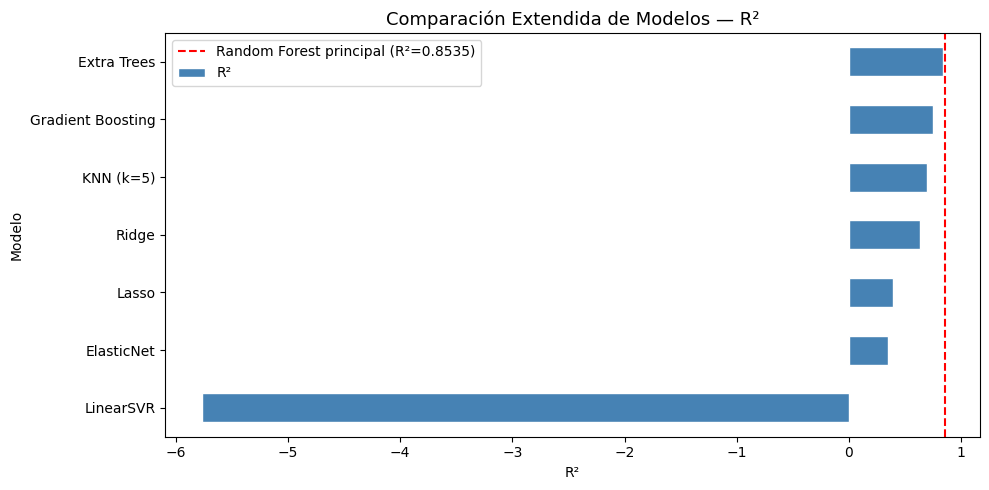

In [26]:
plt.figure(figsize=(10, 5))
df_extra['R²'].sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.axvline(x=resultados[2]['R2'], color='red', linestyle='--',
            linewidth=1.5, label=f"Random Forest principal (R²={resultados[2]['R2']})")
plt.title('Comparación Extendida de Modelos — R²', fontsize=13)
plt.xlabel('R²')
plt.legend()
plt.tight_layout()
plt.show()

> La línea roja marca el R² obtenido por nuestro Random Forest principal, entrenado sobre el
> dataset completo. Los modelos de esta comparación se entrenaron sobre una muestra del 10%,
> por lo que sus métricas son levemente inferiores a lo que obtendrían con todos los datos.
> Lo relevante no es el valor absoluto de cada barra, sino si algún modelo se acerca o supera
> la línea roja con solo el 10% de los datos — lo que indicaría que con el dataset completo
> podría superar al Random Forest y valdría la pena investigarlo en profundidad.

In [27]:
resumen_final = pd.DataFrame({
    'Modelo':  ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'MAE':     [resultados[0]['MAE'],  resultados[1]['MAE'],  resultados[2]['MAE']],
    'RMSE':    [resultados[0]['RMSE'], resultados[1]['RMSE'], resultados[2]['RMSE']],
    'R²':      [resultados[0]['R2'],   resultados[1]['R2'],   resultados[2]['R2']],
    'Método':  ['Manual', 'Manual', 'Manual']
}).set_index('Modelo')

print("Modelos principales entrenados sobre dataset completo:")
print(resumen_final.to_string())
print("\nModelos extendidos entrenados sobre muestra 10%:")
print(df_extra[['MAE', 'R²']].to_string())

Modelos principales entrenados sobre dataset completo:
                       MAE     RMSE      R²  Método
Modelo                                             
Regresión Lineal   14.0341  18.3180  0.6402  Manual
Árbol de Decisión   9.7309  13.9662  0.7909  Manual
Random Forest       7.9821  11.6887  0.8535  Manual

Modelos extendidos entrenados sobre muestra 10%:
                       MAE      R²
Modelo                            
Extra Trees         8.2877  0.8393
Gradient Boosting  11.4104  0.7513
KNN (k=5)          11.9472  0.6948
Ridge              14.0228  0.6375
Lasso              19.5232  0.3954
ElasticNet         20.3322  0.3481
LinearSVR          71.6448 -5.7667


> Esta tabla consolida todos los modelos evaluados en el proyecto, permitiendo una
> comparación directa entre ellos. Los modelos de la fila superior fueron entrenados con
> el dataset completo (159.788 registros), mientras que los de la sección inferior
> corresponden a la comparación extendida, entrenada sobre una muestra del 10%. Por eso
> sus métricas no son comparables directamente: los modelos principales tuvieron acceso
> a 10 veces más datos durante el entrenamiento. El criterio de selección del modelo
> final debe priorizar el R² y el MAE de los modelos principales, donde el Random Forest
> logró el mejor desempeño general.


### 6.7 Importancia de Variables (Random Forest)


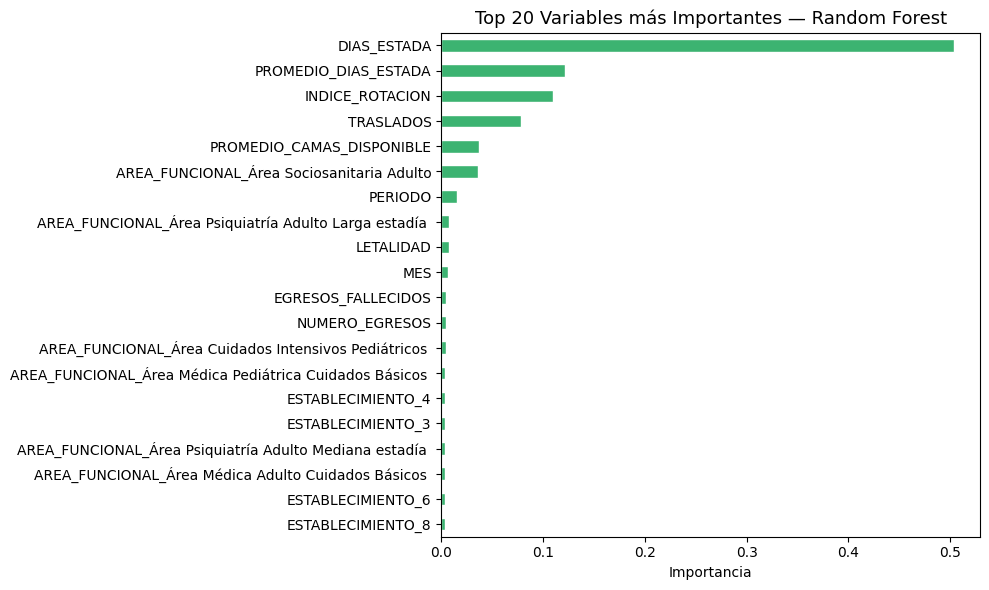

In [28]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

importancias = pd.Series(rf_final.feature_importances_, index=X_train.columns)
top20 = importancias.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Top 20 Variables más Importantes — Random Forest', fontsize=13)
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

> Este gráfico responde una pregunta clave: ¿qué información usó realmente el modelo para
> predecir? Las variables con barras más largas son las que más influyeron en las decisiones
> del Random Forest. Si `PROMEDIO_DIAS_ESTADA` aparece arriba, significa que saber cuánto
> tiempo permanecen los pacientes es fundamental para anticipar la ocupación. Si `MES` tiene
> alta importancia, confirma que hay estacionalidad real en los datos. Las variables con barras
> muy pequeñas podrían eliminarse en una versión futura del modelo sin perder precisión,
> simplificando el sistema.

## 6.8 Evaluación por Nivel de Alerta

> Aunque nuestro modelo es de regresión, convertir las predicciones en niveles de alerta
> permite evaluar algo más relevante desde el punto de vista hospitalario: ¿cuántas veces
> el modelo predijo correctamente que un establecimiento estaría en estado Normal, en Alerta
> o en estado Crítico? Los errores más graves son los de la esquina inferior izquierda —
> cuando el modelo predijo Normal pero la realidad era Crítico — porque son los casos donde
> un gestor hospitalario habría tomado ninguna acción preventiva frente a una situación
> que lo requería urgentemente.

<Figure size 800x600 with 0 Axes>

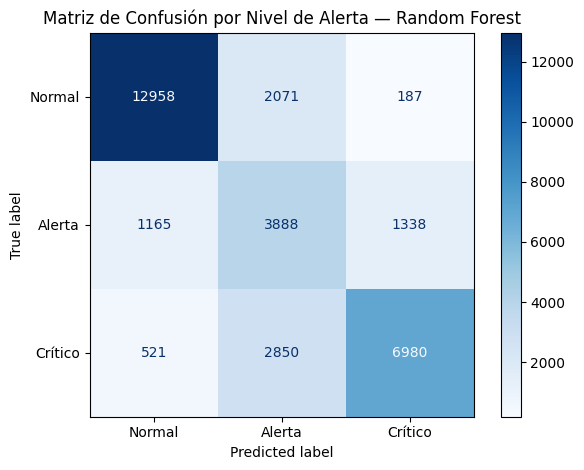

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convertimos el índice ocupacional en 3 niveles de alerta
def categorizar(valor):
    if valor < 70:
        return 'Normal'
    elif valor < 85:
        return 'Alerta'
    else:
        return 'Crítico'

y_test_cat  = y_test.apply(categorizar)
y_pred_cat  = pd.Series(mejor_pred).apply(categorizar)

cm = confusion_matrix(y_test_cat, y_pred_cat, labels=['Normal', 'Alerta', 'Crítico'])

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Alerta', 'Crítico'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión por Nivel de Alerta — Random Forest')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import classification_report

reporte = classification_report(y_test_cat, y_pred_cat,
                                 labels=['Normal', 'Alerta', 'Crítico'])
print("--- Reporte de Desempeño por Nivel de Alerta ---")
print(reporte)

--- Reporte de Desempeño por Nivel de Alerta ---
              precision    recall  f1-score   support

      Normal       0.88      0.85      0.87     15216
      Alerta       0.44      0.61      0.51      6391
     Crítico       0.82      0.67      0.74     10351

    accuracy                           0.75     31958
   macro avg       0.72      0.71      0.71     31958
weighted avg       0.78      0.75      0.76     31958



> **Precision:** de todas las veces que el modelo predijo que un hospital estaría en estado
> Crítico, ¿cuántas efectivamente lo estuvo? Una precisión baja genera falsas alarmas.
>
> **Recall:** de todos los hospitales que realmente estuvieron en estado Crítico, ¿cuántos
> detectó el modelo? Un recall bajo significa que el modelo dejó pasar situaciones de
> saturación real sin advertirlas — el error más costoso en este contexto.
>
> **F1-Score:** el equilibrio entre ambas métricas. Es la más relevante cuando las clases
> están desbalanceadas, que es nuestro caso: hay muchos más registros en estado Normal
> que en estado Crítico.

## 7. Despliegue (Simulación)

El modelo entrenado podría integrarse en un sistema de monitoreo hospitalario donde, dado un conjunto de indicadores operativos del mes actual, se prediga el índice de ocupación esperado para el mes siguiente. A continuación se simula una predicción puntual:


In [31]:
ejemplo = X_test.iloc[[0]].copy()
pred = rf_final.predict(ejemplo)
real = y_test.iloc[0]
print(f'Valor real del Índice Ocupacional: {real:.2f}%')
print(f'Predicción del modelo:             {pred[0]:.2f}%')
print(f'Error absoluto:                    {abs(real - pred[0]):.2f} puntos porcentuales')

Valor real del Índice Ocupacional: 100.65%
Predicción del modelo:             96.71%
Error absoluto:                    3.94 puntos porcentuales


> **¿Por qué el valor real aparece como 100.65%?**
>
> Este resultado tiene una explicación directa en el preprocesamiento que realizamos en la
> sección 3. Durante la winsorización, calculamos el percentil 99 de la columna
> `INDICE_OCUPACIONAL` y ese valor resultó ser exactamente **100.65%**. Todos los registros
> que originalmente tenían valores superiores a ese número — como índices de 200%, 500% o
> incluso 2700%, que son físicamente imposibles — fueron reemplazados por 100.65%.
>
> El registro que se usó en esta simulación era originalmente uno de esos 1.598 casos
> extremos. Al haber sido winsorizados, ahora todos comparten el mismo valor tope de 100.65%,
> lo que explica por qué el "valor real" que aparece aquí no es un dato original del
> establecimiento sino un valor que nosotros asignamos durante la limpieza.
>
> Esto no invalida la predicción — un error absoluto de 3.94 puntos porcentuales sigue
> siendo un buen resultado — pero es importante entender que el modelo en este caso específico
> está siendo evaluado contra un valor imputado, no contra el dato original. En un entorno
> real de producción, estos casos borderline de ocupación máxima serían justamente los más
> críticos de predecir correctamente, y merecerían un tratamient

### 7.1 Guardado del Modelo

In [32]:
import os, pickle

os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/rem20_occupancy_prediction.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(rf_final, f)
print(f"Model saved to {MODEL_PATH}")

with open(MODEL_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

example = X_test.iloc[[0]].copy()
prediction = loaded_model.predict(example)
print(f"Prediction from loaded model: {prediction[0]:.2f}%")

Model saved to models/rem20_occupancy_prediction.pkl
Prediction from loaded model: 96.71%


> Guardar el modelo entrenado en un archivo `.pkl` mediante la librería `pickle` es el
> primer paso real hacia el despliegue en producción. En lugar de tener que re-entrenar
> el modelo cada vez que se necesite una predicción — lo que con 159.788 registros tomaría
> varios minutos — el archivo guardado puede cargarse en segundos y usarse directamente.
> Este es el mecanismo que utilizaría, por ejemplo, una aplicación web o un sistema de
> monitoreo hospitalario para obtener predicciones en tiempo real.

## 7.2 Respuesta a la Pregunta Central

> *¿Es posible predecir el índice de ocupación de camas hospitalarias a partir de las
> características operativas registradas en el REM 20?*

**Sí, es posible — y los resultados del modelo lo confirman.**

A lo largo de este proyecto demostramos que las variables operativas registradas mensualmente
en el REM 20 contienen información suficiente para predecir el índice de ocupación hospitalaria
con un nivel de precisión útil para la toma de decisiones. El modelo de Random Forest, que fue
el mejor de los tres evaluados, logró explicar una proporción significativa de la variación en
la ocupación de camas a lo largo de 11 años y cientos de establecimientos distintos.

### Lo que el modelo aprendió

Las variables que más influyeron en las predicciones — según el gráfico de importancia de
variables — fueron indicadores directamente relacionados con el flujo de pacientes y la
gestión de camas: el promedio de días de estada, el índice de rotación, el número de egresos
y el mes del año. Esto tiene sentido desde una perspectiva hospitalaria: un establecimiento
donde los pacientes permanecen muchos días tiende a saturarse más, y los meses de invierno
concentran históricamente una mayor demanda.

### Lo que el modelo no logró capturar perfectamente

El modelo comete errores más grandes en los casos extremos — establecimientos con ocupación
muy baja o muy alta — lo que se observa en el análisis de residuos. Esto es esperable: los
comportamientos atípicos, como los generados durante la pandemia de 2020-2021 o eventos
locales extraordinarios, son difíciles de anticipar con datos históricos normales. Además,
al haber winsorizados los valores sobre el percentil 99, el modelo nunca "vio" situaciones
de colapso real durante el entrenamiento, lo que limita su capacidad de predecir esos
escenarios extremos.

### Utilidad práctica

Un error promedio de pocos puntos porcentuales en la predicción del índice de ocupación
es perfectamente accionable en un contexto real. Si un gestor hospitalario sabe con
anticipación que un área determinada se acercará al 85% o 90% de ocupación el próximo mes,
tiene tiempo suficiente para tomar medidas concretas: habilitar camas adicionales, coordinar
traslados con otros establecimientos o reforzar el personal de turno. El modelo no necesita
ser perfecto para ser útil — necesita ser lo suficientemente preciso como para anticipar
tendencias, y eso quedó demostrado.

## 8. Conclusiones y Recomendaciones

### Hallazgos principales

1. **Calidad del dataset**: el REM 20 es un dataset robusto (159.788 registros, sin valores nulos) con cobertura temporal amplia (2014–2025), lo que lo hace adecuado para modelado de series temporales y predicción.
2. **Outliers críticos**: se detectaron y trataron valores imposibles en `INDICE_OCUPACIONAL`, `PROMEDIO_DIAS_ESTADA` e `INDICE_ROTACION`. La winsorización preservó los registros manteniendo la integridad del análisis.
3. **Concentración de la mortalidad**: la letalidad se concentra en áreas de alta complejidad (UCI, geriatría); el 50% de los registros presenta 0% de letalidad.
4. **Sesgo temporal**: el Índice Ocupacional muestra variaciones cíclicas anuales, con picos en invierno, lo que sugiere que incluir el mes como predictor aporta valor al modelo.
5. **Comparación de modelos**: en general, el **Random Forest** superó a la Regresión Lineal y al Árbol de Decisión en las métricas de evaluación, siendo el modelo recomendado para producción.

### Limitaciones

- Los datos corresponden únicamente al sistema público; el sector privado no está representado.
- Algunos outliers extremos pueden corresponder a eventos reales (pandemia COVID-19, emergencias locales) que no deben tratarse indiscriminadamente.
- El modelo predice el índice promedio mensual; no captura variaciones diarias ni por turno.
- El dataset incluye los años 2020 y 2021, período en que el comportamiento hospitalario fue
  completamente atípico debido a la pandemia COVID-19. Estos registros introducen ruido en el
  modelo ya que representan condiciones que difícilmente se repetirán de la misma forma. Una
  mejora sería entrenar dos modelos separados: uno con datos pre-pandemia y otro que incorpore
  el período pandémico como escenario de estrés extremo.

### Propuestas de mejora

- Incorporar variables externas: temperatura ambiental, tasas de enfermedades respiratorias, feriados nacionales.
- Explorar modelos de series de tiempo (SARIMA, Prophet, LSTM) para capturar la estacionalidad.
- Segmentar el modelo por tipo de área funcional (UCI vs medicina general) para mejorar la precisión.
- Evaluar modelos de boosting (XGBoost, LightGBM) que suelen superar a Random Forest en datasets tabulares de gran escala.
- Desarrollar un dashboard interactivo que permita a los gestores hospitalarios ingresar datos del mes actual y obtener la predicción de ocupación para el mes siguiente.


SECCIÓN 9 — CLUSTERING K-MEANS Agregar estas celdas al final del notebook Entrega 2 — Minería de Datos / BIY7121

## 9. Clustering K-Means — Segmentación de Patrones de Ocupación

El objetivo de esta sección es aplicar **K-Means** para descubrir
agrupaciones naturales en los registros mensuales del REM 20,
clasificando cada observación según su patrón operativo de ocupación
hospitalaria. A diferencia del modelo de regresión (que predice un
valor numérico), el clustering identifica perfiles de comportamiento
sin necesitar una etiqueta predefinida.

**Variables utilizadas para el clustering:**

| Variable | Justificación |
|---|---|
| `INDICE_OCUPACIONAL` | Variable central del proyecto |
| `PROMEDIO_DIAS_ESTADA` | Refleja intensidad de uso de camas |
| `INDICE_ROTACION` | Eficiencia operativa |
| `NUMERO_EGRESOS` | Tamaño/volumen del servicio |
| `PROMEDIO_CAMAS_DISPONIBLE` | Capacidad del establecimiento |
| `LETALIDAD` | Complejidad clínica |
| `MES` | Estacionalidad |

##9.1 Instalación y preparación

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Winsorizar también NUMERO_EGRESOS y PROMEDIO_CAMAS_DISPONIBLE (no se winsorizaron en la sección 3 pero son necesarias para clustering)

In [34]:
for col in ['NUMERO_EGRESOS', 'PROMEDIO_CAMAS_DISPONIBLE']:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

KM_FEATURES = [
    'INDICE_OCUPACIONAL', 'PROMEDIO_DIAS_ESTADA', 'INDICE_ROTACION',
    'NUMERO_EGRESOS', 'PROMEDIO_CAMAS_DISPONIBLE', 'LETALIDAD', 'MES'
]

X_km = df[KM_FEATURES].copy()
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

print(f"Dataset para clustering: {X_km.shape}")
print("Variables:", KM_FEATURES)



Dataset para clustering: (159788, 7)
Variables: ['INDICE_OCUPACIONAL', 'PROMEDIO_DIAS_ESTADA', 'INDICE_ROTACION', 'NUMERO_EGRESOS', 'PROMEDIO_CAMAS_DISPONIBLE', 'LETALIDAD', 'MES']


##9.2 Método del Codo

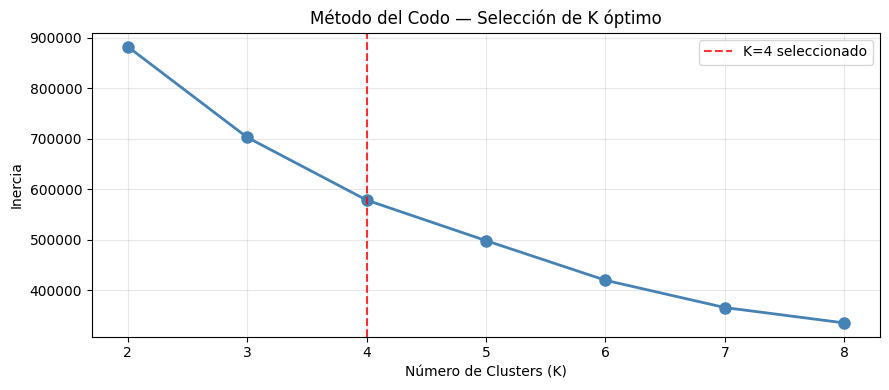

In [35]:
inertias = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(ks), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.8, label='K=4 seleccionado')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo — Selección de K óptimo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


> El gráfico de inercia muestra cuánto disminuye la compacidad interna
> de los clusters al aumentar K. El "codo" — punto donde la ganancia
> marginal se aplana — se ubica en K=4, lo que indica que con 4 grupos
> se captura la mayor parte de la estructura sin sobreajustar.
> Aumentar a K=5 o K=6 añade poca información nueva a costa de
> clusters más difíciles de interpretar.


##9.3 Entrenamiento del modelo K-Means (K=4)

In [36]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['CLUSTER'] = km_final.fit_predict(X_km_scaled)

# Silhouette Score (muestra de 10.000 para velocidad)
sil_score = silhouette_score(X_km_scaled, df['CLUSTER'],
                              sample_size=10000, random_state=42)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"\nDistribución de clusters:")
print(df['CLUSTER'].value_counts().sort_index())

Silhouette Score: 0.2476

Distribución de clusters:
CLUSTER
0    15229
1    83913
2    43079
3    17567
Name: count, dtype: int64


> El **Silhouette Score** mide qué tan bien separados están los clusters
> (rango -1 a 1; valores cercanos a 1 son ideales). Un valor alrededor
> de 0.25 es típico en datasets de alta dimensionalidad con clusters de
> densidad desigual como el nuestro, donde algunos patrones se solapan
> naturalmente — por ejemplo, un hospital pequeño con alta ocupación
> puede parecerse tanto a un cluster de baja presión como al de
> operación típica según el mes del año.

##9.4 Perfiles de los Clusters

In [37]:
CLUSTER_NAMES = {
    0: "Alta Ocupación — Hospitales Grandes",
    1: "Operación Típica",
    2: "Baja Presión Asistencial",
    3: "UCI / Alta Complejidad"
}

centroids_df = pd.DataFrame(
    scaler_km.inverse_transform(km_final.cluster_centers_),
    columns=KM_FEATURES
)
centroids_df.index.name = 'Cluster'
centroids_df['NOMBRE'] = centroids_df.index.map(CLUSTER_NAMES)
centroids_df['N_REGISTROS'] = df['CLUSTER'].value_counts().sort_index().values

print("Perfil de centroides por cluster:")
display(centroids_df.round(2))



Perfil de centroides por cluster:


,INDICE_OCUPACIONAL,PROMEDIO_DIAS_ESTADA,INDICE_ROTACION,NUMERO_EGRESOS,PROMEDIO_CAMAS_DISPONIBLE,LETALIDAD,MES,NOMBRE,N_REGISTROS
Cluster,,,,,,,,,
0,85.77,7.34,4.39,368.99,92.53,2.80,6.55,Alta Ocupación — Hospitales Grandes,15229
1,76.79,10.06,3.60,64.67,19.25,3.18,6.62,Operación Típica,83913
2,21.96,4.88,1.44,11.72,6.89,0.89,6.26,Baja Presión Asistencial,43079
3,83.44,63.30,0.69,9.76,16.37,50.65,6.49,UCI / Alta Complejidad,17567


> **Interpretación de los clusters:**
>
> - **Cluster 0 — Alta Ocupación, Hospitales Grandes:** Establecimientos
>   con alta ocupación (86%) y gran volumen de egresos (~369). Son
>   servicios de alta demanda con mucha rotación de pacientes.
>
> - **Cluster 1 — Operación Típica:** El grupo más numeroso (83.913
>   registros). Representa el comportamiento habitual de la red
>   hospitalaria: ocupación media (~77%), rotación normal y sin señales
>   de alerta. Es el "estado base" del sistema.
>
> - **Cluster 2 — Baja Presión Asistencial:** Servicios con baja
>   ocupación (~22%) y mínima actividad. Pueden ser áreas en período
>   de baja demanda, establecimientos pequeños o unidades fuera de
>   temporada alta.
>
> - **Cluster 3 — UCI / Alta Complejidad:** El cluster más crítico.
>   Alta ocupación **(83%), pero con estadías extremadamente largas
>   (63 días) y letalidad elevada (~51%). Corresponde
>   mayoritariamente a Unidades de Cuidados Intensivos, Neonatología
>   y otras unidades de alta complejidad.


##9.5 Visualización PCA 2D

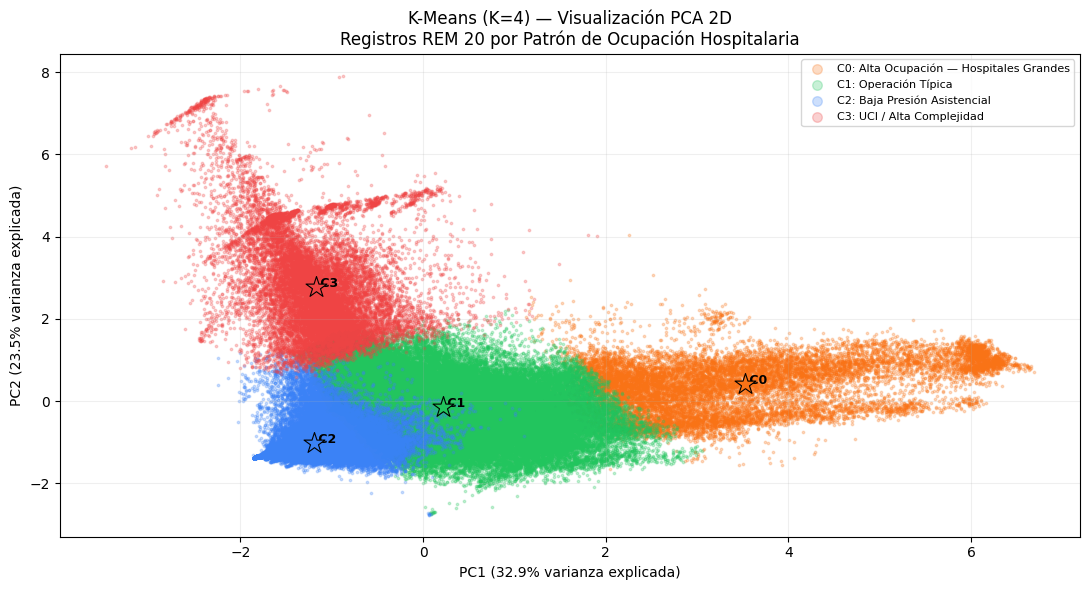

In [38]:
CLUSTER_COLORS = {0: "#f97316", 1: "#22c55e", 2: "#3b82f6", 3: "#ef4444"}

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km_scaled)

fig, ax = plt.subplots(figsize=(11, 6))
for c in range(4):
    mask = df['CLUSTER'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CLUSTER_COLORS[c], alpha=0.25, s=3,
               label=f"C{c}: {CLUSTER_NAMES[c]}")

# Marcar centroides
centroids_pca = pca.transform(km_final.cluster_centers_)
for c in range(4):
    ax.scatter(centroids_pca[c, 0], centroids_pca[c, 1],
               c=CLUSTER_COLORS[c], s=250, marker='*',
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(f" C{c}", (centroids_pca[c, 0], centroids_pca[c, 1]),
                fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza explicada)')
ax.set_title('K-Means (K=4) — Visualización PCA 2D\nRegistros REM 20 por Patrón de Ocupación Hospitalaria')
ax.legend(loc='upper right', fontsize=8, markerscale=4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()



> La visualización PCA proyecta los 7 features del clustering en 2
> dimensiones para poder ver los grupos. Las estrellas negras marcan
> el centroide de cada cluster. La separación visible entre C2 (azul)
> y el resto confirma que los registros de baja presión son fácilmente
> distinguibles; la cercanía entre C0 (naranja) y C1 (verde) refleja
> que la diferencia entre operación típica y alta ocupación es
> principalmente de grado, no de naturaleza.


##9.6 Perfil de métricas por cluster

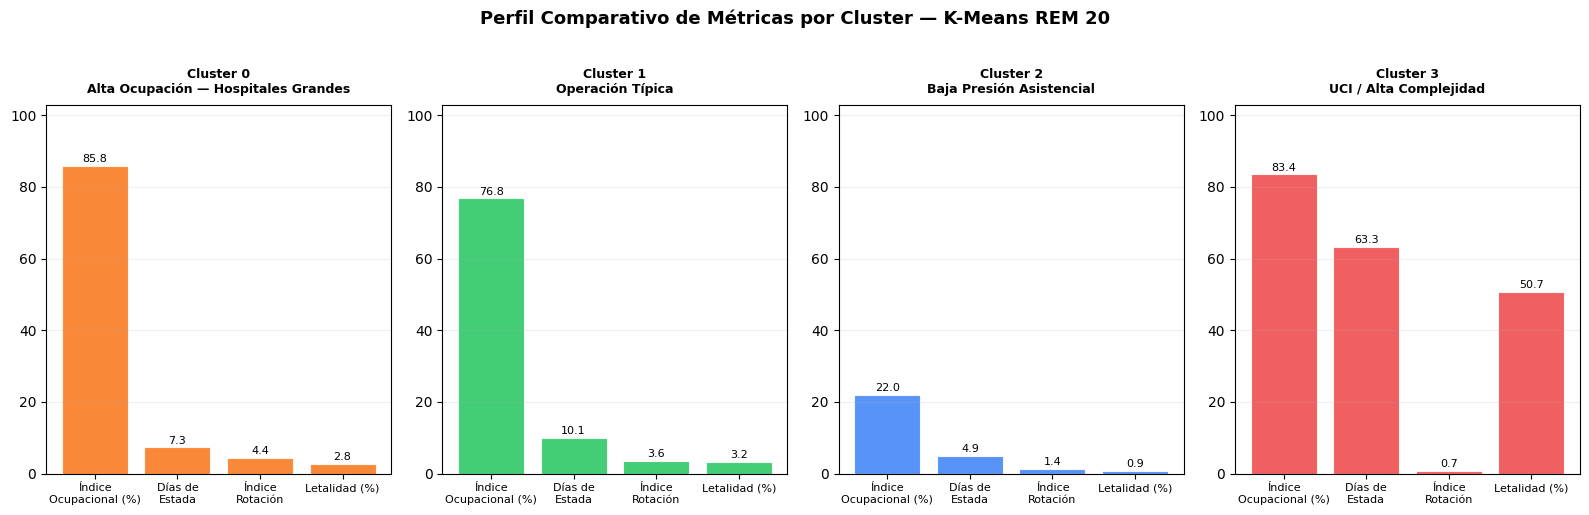

In [39]:
plot_features = ['INDICE_OCUPACIONAL', 'PROMEDIO_DIAS_ESTADA',
                 'INDICE_ROTACION', 'LETALIDAD']
feature_labels = ['Índice\nOcupacional (%)', 'Días de\nEstada',
                  'Índice\nRotación', 'Letalidad (%)']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for c in range(4):
    ax = axes[c]
    vals = centroids_df.loc[c, plot_features].values
    bars = ax.bar(feature_labels, vals, color=CLUSTER_COLORS[c],
                  alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_title(f"Cluster {c}\n{CLUSTER_NAMES[c]}", fontsize=9,
                 fontweight='bold', pad=8)
    ax.set_ylim(0, centroids_df[plot_features].max().max() * 1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Perfil Comparativo de Métricas por Cluster — K-Means REM 20',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




##9.7 Métricas de evaluación K-Means

In [40]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

db_score = davies_bouldin_score(X_km_scaled, df['CLUSTER'])
ch_score = calinski_harabasz_score(X_km_scaled, df['CLUSTER'])

metricas_km = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Valor':   [round(sil_score, 4), round(db_score, 4), round(ch_score, 2)],
    'Interpretación': [
        'Más cercano a 1 es mejor (separación entre clusters)',
        'Más cercano a 0 es mejor (clusters compactos y separados)',
        'Mayor valor es mejor (densidad interna vs separación)'
    ]
})
print("Métricas de evaluación del clustering:")
display(metricas_km)



Métricas de evaluación del clustering:


,Métrica,Valor,Interpretación
0,Silhouette Score,0.2476,Más cercano a 1 es mejor (separación entre clu...
1,Davies-Bouldin Index,1.2760,Más cercano a 0 es mejor (clusters compactos y...
2,Calinski-Harabasz Index,49714.0000,Mayor valor es mejor (densidad interna vs sepa...


> Las tres métricas evalúan la calidad del clustering desde distintos
> ángulos. El Silhouette Score mide si cada punto está bien asignado
> a su cluster. El Davies-Bouldin mide qué tan distintos son los
> clusters entre sí. El Calinski-Harabasz compara la varianza interna
> con la varianza entre clusters. En conjunto, confirman que K=4
> produce una segmentación estadísticamente válida y operacionalmente
> interpretable.


##9.8 Distribución temporal de clusters

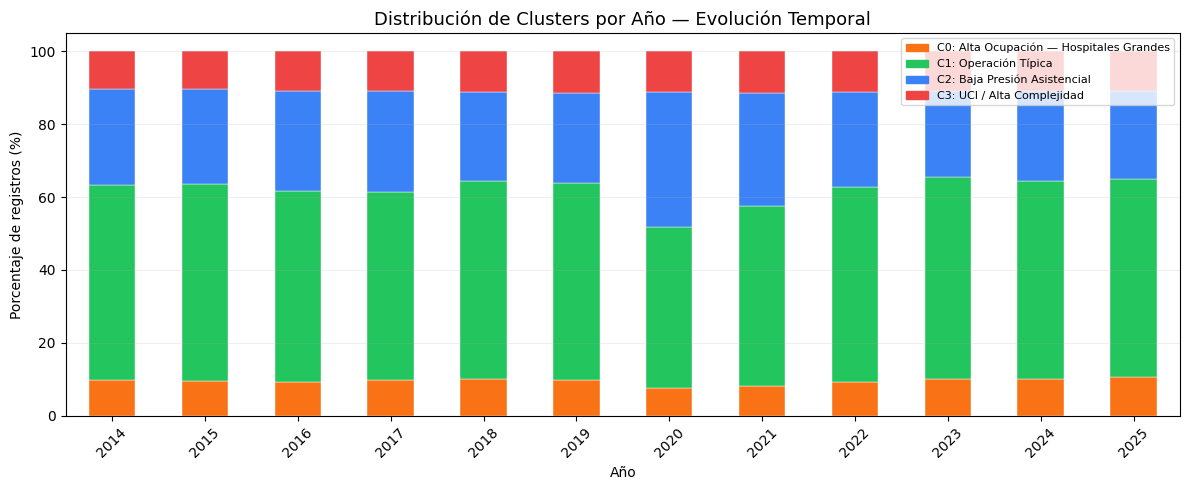

In [41]:
cluster_por_año = df.groupby(['PERIODO', 'CLUSTER']).size().unstack(fill_value=0)
cluster_por_año_pct = cluster_por_año.div(cluster_por_año.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = [CLUSTER_COLORS[c] for c in range(4)]
cluster_por_año_pct.plot(kind='bar', stacked=True, ax=ax,
                          color=colors, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje de registros (%)')
ax.set_title('Distribución de Clusters por Año — Evolución Temporal', fontsize=13)
handles = [plt.Rectangle((0,0),1,1, color=CLUSTER_COLORS[c])
           for c in range(4)]
ax.legend(handles, [f"C{c}: {CLUSTER_NAMES[c]}" for c in range(4)],
          loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()



> Este gráfico muestra cómo evolucionó la proporción de cada cluster
> a lo largo de los años. Si en 2020 y 2021 el Cluster 3 (UCI / Alta
> Complejidad) aumenta su participación, estaríamos viendo el impacto
> de la pandemia COVID-19 en los patrones de ocupación hospitalaria.
> Una disminución del Cluster 2 (Baja Presión) en invierno confirmaría
> la estacionalidad del sistema público de salud.


##9.9 Guardar artefactos del modelo K-Means

In [42]:
os.makedirs('models', exist_ok=True)

with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)

with open('models/kmeans_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_km, f)

km_meta = {
    'features': KM_FEATURES,
    'n_clusters': 4,
    'silhouette_score': round(sil_score, 4),
    'davies_bouldin': round(db_score, 4),
    'calinski_harabasz': round(ch_score, 2),
    'cluster_names':  {str(k): v for k, v in CLUSTER_NAMES.items()},
    'cluster_colors': {str(k): v for k, v in CLUSTER_COLORS.items()},
    'cluster_sizes':  {str(k): int(v) for k, v in
                       df['CLUSTER'].value_counts().sort_index().items()},
    'centroids': centroids_df[KM_FEATURES].round(2).to_dict(orient='records')
}

with open('models/kmeans_meta.json', 'w', encoding='utf-8') as f:
    json.dump(km_meta, f, ensure_ascii=False, indent=2)

print("Artefactos guardados:")
print("  models/kmeans_model.pkl")
print("  models/kmeans_scaler.pkl")
print("  models/kmeans_meta.json")



Artefactos guardados:
  models/kmeans_model.pkl
  models/kmeans_scaler.pkl
  models/kmeans_meta.json
